# 0. Preparation

In [ ]:
# 安装依赖
# !pip install -qU peft accelerate datasets einops ipywidgets

In [2]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HUB_ENDPOINT'] = 'https://hf-mirror.com'
import copy
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm
from typing import List
from einops import rearrange
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoTokenizer, AutoModel, AutoModelForCausalLM

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.bfloat16 if device != 'cpu' and torch.cuda.is_bf16_supported() else torch.float32
print(f'device: {device}\ndtype: {dtype}')

/environment/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
dtype: torch.bfloat16


# 1. LoRA Dry Run

先使用一个极小参数的 llama 模型 dry run，验证 lora 是否正常工作。

In [3]:
config = AutoConfig.for_model('llama')  # 获取LLaMA架构的默认配置模板
config.hidden_size = 24  # 隐藏层维度
config.intermediate_size = config.hidden_size * 4  # 中间层维度（FFN层）
config.num_attention_heads = 4  # 注意力头数量
config.num_hidden_layers = 4  # Transformer层数
config.num_key_value_heads = 2  # 键值头数量（GQA分组查询注意力）
config.vocab_size = 128  # 词表大小
config.head_dim = config.hidden_size // config.num_attention_heads  # 每个头的维度（新版Transformers需要显式指定）

In [4]:
raw_model = AutoModel.from_config(config)
raw_model

LlamaModel(
  (embed_tokens): Embedding(128, 24)
  (layers): ModuleList(
    (0-3): 4 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=24, out_features=24, bias=False)
        (k_proj): Linear(in_features=24, out_features=12, bias=False)
        (v_proj): Linear(in_features=24, out_features=12, bias=False)
        (o_proj): Linear(in_features=24, out_features=24, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=24, out_features=96, bias=False)
        (up_proj): Linear(in_features=24, out_features=96, bias=False)
        (down_proj): Linear(in_features=96, out_features=24, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((24,), eps=1e-06)
      (post_attention_layernorm): LlamaRMSNorm((24,), eps=1e-06)
    )
  )
  (norm): LlamaRMSNorm((24,), eps=1e-06)
  (rotary_emb): LlamaRotaryEmbedding()
)

## LoRA 类定义

**LoRA forward：**
$$
W = W_0 + \Delta W
  = W_0 + \frac{\alpha}{r}BA
$$

$$
\begin{aligned}
\mathbf{y} &= W_0\mathbf{x} + \Delta W \mathbf{x} \\[4pt]
           &= W_0\mathbf{x} + \frac{\alpha}{r} \cdot BA \cdot \mathbf{x}
\end{aligned}
$$

矩阵分析：
$$
\begin{aligned}
\mathbf{x} &\in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times d_{\text{in}}} \\[4pt]
A &\in \mathbb{R}^{\,r \times d_{\text{in}}},
\quad
B \in \mathbb{R}^{\,d_{\text{out}} \times r} \\[8pt]
\mathbf{h} &= \mathbf{x} \cdot A^{\top}
            \in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times r} \\[4pt]
\Delta\mathbf{y} &= \mathbf{h} \cdot B^{\top}
                  = \mathbf{x} \cdot A^{\top} \cdot B^{\top}
                  \in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times d_{\text{out}}} \\[4pt]
\mathbf{y} &= W_0\mathbf{x} + \frac{\alpha}{r} \cdot \Delta\mathbf{y}
            \in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times d_{\text{out}}}
\end{aligned}
$$

In [5]:
class LoraLinear(nn.Module):
    def __init__(
        self,
        base_layer: nn.Linear,      # 原来的线性层
        r: int = 8,                 # lora rank
        alpha: int = 16,            # lora alpha
        dropout_p: float = 0.0,     # lora dropout
        test_mode: bool = False,    # 测试模式，用于控制 lora_B 是否为全零
    ):
        super(LoraLinear, self).__init__() # super 找到 LoraLinear 的父类（nn.Module）的 __init__ 方法
        self.base_layer = copy.deepcopy(base_layer) # 把传入的原始线性层拷贝一份存起来，这样修改 LoRA 层不会影响原始模型
        self.r = r
        self.alpha = alpha
        self.dropout = nn.Dropout(dropout_p)

        # 定义 lora_A 和 lora_B 为 Parameter
        # 下投影矩阵 A
        self.lora_A = nn.Parameter(torch.empty((r, base_layer.in_features), dtype=base_layer.weight.dtype))
        # 上投影矩阵 B
        self.lora_B = nn.Parameter(torch.empty((base_layer.out_features, r), dtype=base_layer.weight.dtype))

        # 初始化 lora 矩阵
        nn.init.normal_(self.lora_A, mean=0.0, std=0.02)
        if test_mode:
            nn.init.normal_(self.lora_B, mean=0.0, std=0.02)
        else:
            nn.init.zeros_(self.lora_B)

        # 冻结原来的层的参数
        for param in self.base_layer.parameters():
            param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scaling = float(self.alpha) / float(self.r)     # lora 缩放系数
        lora_adjustment = F.linear(self.dropout(x), self.lora_A) # linear 会计算 h = x @ lora_A.T
        lora_adjustment = F.linear(lora_adjustment, self.lora_B) # linear 会计算 lora_adjustment = h @ lora_B.T
        return self.base_layer(x) + lora_adjustment * scaling

## 替换 LoRA 部分

In [6]:
def replace_linear_with_lora(
    module: nn.Module,
    r: int = 8,
    alpha: int = 16,
    dropout_p: float = 0.0,
    embed_requires_grad: bool = False,      # embedding 层是否训练
    norm_requires_grad: bool = False,       # norm 层是否训练
    head_requires_grad: bool = False,       # lm_head 层是否训练（Causal LM才有）
    test_mode: bool = False,                # 测试模式，用于控制 lora_B 是否为全零
):
    """
    找到 module 中所有线性层并递归替换
    """
    for name, child in module.named_children():
        # 先处理额外的层，lm_head 也是 linear，所以先处理
        if any(s in name for s in ['embed', 'norm', 'lm_head']):
            requires_grad = embed_requires_grad if 'embed' in name \
                            else norm_requires_grad if 'norm' in name \
                            else head_requires_grad
            for param in child.parameters():
                param.requires_grad = requires_grad
        # 替换所有线性层，QLoRA 做法
        elif isinstance(child, nn.Linear):
            lora_linear = LoraLinear(child, r=r, alpha=alpha, dropout_p=dropout_p, test_mode=test_mode)
            setattr(module, name, lora_linear)
        # 递归向下替换
        else:
            replace_linear_with_lora(
                child, r, alpha, dropout_p,
                embed_requires_grad, norm_requires_grad, head_requires_grad,
                test_mode=test_mode
            )

In [7]:
def unload_lora(module: nn.Module, adapter_name: str = 'adapter'):
    """
    卸载 lora 参数，并将原模型恢复至加载 lora 前的样子
    """
    lora_parameters = {} # 准备一个空字典，用来收集所有 LoRA 层的参数
    def search_lora_linear(module: nn.Module, prefix: List[str]):
        """
        递归搜索模块中的所有 LoRA 层，将参数保存到 lora_parameters 中
        """
        for name, child in module.named_children():
            new_prefix = prefix + [name]
            if isinstance(child, LoraLinear):
                # 保存 lora 参数
                lora_parameters['.'.join(new_prefix)] = {
                    "lora_A_weight": child.lora_A.data.cpu(),
                    "lora_B_weight": child.lora_B.data.cpu(),
                    "r": child.r,
                    "alpha": child.alpha,
                    "dropout_p": child.dropout.p,
                }
                setattr(module, name, child.base_layer)
            else:
                search_lora_linear(child, new_prefix)

    search_lora_linear(module, [])
    # 解冻原模型
    for name, param in module.named_parameters():
        param.requires_grad = True

    torch.save(lora_parameters, f"{adapter_name}.pt") # 将 lora 参数保存为 .pt 文件

In [8]:
def load_lora(module: nn.Module, adapter_name: str = 'adapter'):
    """
    从 .pt 文件中加载 lora 参数
    """
    lora_parameters = torch.load(f"{adapter_name}.pt")

    for name, lora_params in lora_parameters.items():
        child = dict(module.named_modules())[name]
        if isinstance(child, nn.Linear):
            lora_linear = LoraLinear(child, lora_params['r'], lora_params['alpha'], lora_params['dropout_p'])
            lora_linear.lora_A.data = lora_params["lora_A_weight"].to(lora_linear.lora_A.device)
            lora_linear.lora_B.data = lora_params["lora_B_weight"].to(lora_linear.lora_B.device)

            # 名称示例：layers.0.self_attn.q_proj
            # 根据名称循环找到所需 module
            parts = name.split(".")
            obj = module
            for part in parts[:-1]:  # 不包括最后一级
                obj = getattr(obj, part)
            setattr(obj, parts[-1], lora_linear)

    # 恢复原来的冻结方式，这里简单地除了 lora 全冻结
    for name, param in module.named_parameters():
        if any(s in name for s in ['embed', 'norm', 'lm_head']):
            param.requires_grad = False

## LoRA 尝试

In [9]:
def print_trainable_parameters(model: nn.Module):
    """
    打印可训练参数，和 PeftModel 的方法类似
    """
    total_params = sum(p.numel() for p in model.parameters()) # 计算模型的所有参数数量
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) # 计算可训练参数数量
    trainable_percentage = 100 * trainable_params / total_params # 计算可训练参数占比

    print(f"trainable params: {trainable_params:,} || all params: {total_params:,} || trainable%: {trainable_percentage:.4f}")

LoRA 前的参数情况：

In [10]:
print_trainable_parameters(raw_model)

trainable params: 37,848 || all params: 37,848 || trainable%: 100.0000


LoRA 后的参数情况：

In [11]:
lora_model = copy.deepcopy(raw_model)
replace_linear_with_lora(lora_model)
print_trainable_parameters(lora_model)

trainable params: 16,896 || all params: 54,744 || trainable%: 30.8637


测试 load 和 unload：

In [12]:
# 创建一个测试 tensor
bsz = 2 # 批量大小
seq_len = 8 # 序列长度
test_tensor = torch.randint(0, config.vocab_size, (bsz, seq_len))
# raw_model(test_tensor)    原始模型输出
# lora_model(test_tensor)   带 LoRA 输出

In [13]:
# 开测试模式，让 BA 非零
lora_model = copy.deepcopy(raw_model)
replace_linear_with_lora(lora_model, test_mode=True)

In [14]:
# 原模型的前向结果
raw_model.eval() # .eval() 把模型内部所有子模块的 training 标志全部设为 False
print_trainable_parameters(raw_model)   # 检查参数和可训练情况
raw_res = raw_model(test_tensor).last_hidden_state

trainable params: 37,848 || all params: 37,848 || trainable%: 100.0000


In [15]:
# 第一次直接初始化 lora 的前向结果
lora_model.eval()
print_trainable_parameters(lora_model)  # 检查参数和可训练情况
before_unload_res = lora_model(test_tensor).last_hidden_state

trainable params: 16,896 || all params: 54,744 || trainable%: 30.8637


In [16]:
# 卸载 lora 后的前向结果
unload_lora(lora_model)
lora_model.eval()
print_trainable_parameters(lora_model)  # 检查参数和可训练情况
unload_res = lora_model(test_tensor).last_hidden_state

trainable params: 37,848 || all params: 37,848 || trainable%: 100.0000


In [17]:
# 重新装载 lora 后的前向结果
load_lora(lora_model)
lora_model.eval()
print_trainable_parameters(lora_model)  # 检查参数和可训练情况
load_res = lora_model(test_tensor).last_hidden_state

trainable params: 16,896 || all params: 54,744 || trainable%: 30.8637


In [18]:
print(torch.allclose(raw_res, unload_res, atol=1e-6))           # 应为 True：卸载 LoRA 后模型回到原始状态
print(torch.allclose(before_unload_res, load_res, atol=1e-6))   # 应为 True：重新加载 LoRA 后和卸载前完全一致
print(torch.allclose(raw_res, load_res, atol=1e-6))             # 应为 False：test_mode 让 BA 非零，确实改变了模型输出

True
True
False


# 2. LoRA 实战

## 模型

模型选择 [Qwen/Qwen1.5-0.5B](https://huggingface.co/Qwen/Qwen1.5-0.5B)，表现不够强，方便观察 LoRA 效果。<br>
数据集选择 [bio-nlp-umass/bioinstruct](https://huggingface.co/datasets/bio-nlp-umass/bioinstruct)，这是一个生物医学指令数据集，用于微调模型。

In [19]:
model_name_or_path = 'Qwen/Qwen1.5-0.5B'
data_name_or_path = 'bio-nlp-umass/bioinstruct'

In [20]:
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path) # 从 Hugging Face 自动加载与模型匹配的分词器，会自动找到对应的 tokenizer 配置
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = 'left'

model = AutoModelForCausalLM.from_pretrained(model_name_or_path, dtype=dtype).to(device)
# AutoModelForCausalLM：Transformers 提供的自动模型类，用于加载因果语言模型（Causal Language Model），例如 Qwen、LLaMA、GPT。因果语言模型根据前面的 Token 预测下一个 Token，适用于文本生成和对话任务。
# .from_pretrained(model_name_or_path)：从 Hugging Face Hub 或本地目录加载预训练模型。

Loading weights: 100%|██████████| 291/291 [00:00<00:00, 4932.36it/s]


dtype 指定模型权重的数据类型：
```python
dtype = (
    torch.bfloat16
    if device != "cpu" and torch.cuda.is_bf16_supported()
    else torch.float32
)
```
- BF16：16位浮点数
- BF32：32位浮点数

- GPU 支持 BF16：使用 torch.bfloat16 ，减少显存占用并提高计算速度；
- 使用 CPU 或 GPU 不支持 BF16：使用 torch.float32 ，兼容性更好。

例如，0.5B 参数模型仅计算参数权重时：
- FP32 大约占 0.5B × 4 Bytes ≈ 2 GB ；<br>
0.5B × 4 Bytes = 2B Bytes <br>
1B = 1,000,000,000 ≈ $1024^3$，**即 `1 Billion ≈ 1G`** <br>
故 2B Bytes ≈ 2 × $1024^3$ Bytes ≈ 2 GB <br>
- BF16 大约占 0.5B × 2 Bytes ≈ 1 GB 。

In [21]:
# 获取 lora model
replace_linear_with_lora(model, r=8, alpha=16, dropout_p=0.0)
model.to(device)

# 查看可训练参数
print_trainable_parameters(model)

trainable params: 3,784,704 || all params: 467,772,416 || trainable%: 0.8091


**关于这里的 model.to(device)：** <br>
<br>
`model = AutoModelForCausalLM.from_pretrained(...).to(device)` 之后，模型已经在 GPU 上了。<br>
但是调用 `replace_linear_with_lora(...)` 时，创建的 lora_A 和 lora_B 默认设备是 CPU。<br>
```python
self.lora_A = nn.Parameter(torch.empty((r, in_features), ...))   # ← torch.empty()默认在 CPU 创建！
self.lora_B = nn.Parameter(torch.empty((out_features, r), ...))  # ← torch.empty()默认在 CPU 创建！
```
所以执行完 replace_linear_with_lora 之后
```
model 的参数分布：
  ├── embed_tokens      → GPU  ✅
  ├── layers            → GPU  ✅
  ├── lora_A（新增的）   → CPU  ❌
  ├── lora_B（新增的）   → CPU  ❌
  └── ...
```
训练时 forward 会做矩阵乘法：`x @ lora_A.T`，PyTorch 不允许 GPU 张量和 CPU 张量之间做运算。<br>

`model.to(device)` 会把模型的 所有参数 （不管原来在哪）都搬到 device （GPU），这就解决了该问题。

## 数据集

In [22]:
# 定义训练数据集
class SFTDataset(Dataset):
    def __init__(self,
        tokenizer: AutoTokenizer,
        data_path: str,
        load_local: bool = False,
        max_len: int = 256,
        split_len: str = '1%',
    ):
        super().__init__() # 调用 PyTorch Dataset 基类初始化
        self.tokenizer = tokenizer

        if load_local:
            # 加载完整数据集
            ds = load_dataset('json', data_dir=data_path, split=f'train[:{split_len}]')
        else:
            # 只取训练集的前 1%，数据量小，适合快速试跑
            ds = load_dataset(data_path, split=f'train[:{split_len}]')
        self.max_len = max_len

        def process_func(example):
            # 提取 instruction、input 和 output
            instruction = example['instruction'].strip()
            input = example['input'].strip()
            output = example['output'].strip()

            # 构造输入模板
            instruction_msg = [
                {"role": "user", "content": (instruction + f"\n{input}") if len(input) > 0 else instruction}
            ]
            
            # apply_chat_template 是 Transformers 提供的方法，根据 Qwen 的聊天模板自动添加特殊 Token
            # 使用 tokenizer 进行分词
            tokenized_instruction = tokenizer.apply_chat_template(instruction_msg,tokenize=True,add_generation_prompt=True,)["input_ids"]
            tokenized_output = tokenizer(output + "<|im_end|>" + f"{tokenizer.eos_token}\n")['input_ids']

            # 截断，最大不超过 max_len
            tokenized_prompt = (tokenized_instruction + tokenized_output)[:self.max_len]

            # 构造 input_ids, attention_mask, labels
            input_ids = tokenized_prompt[:-1]
            attention_mask = [1] * len(input_ids)
            labels = tokenized_prompt[1:]

            # instruction 部分不计算 loss
            instruction_label_len = len(tokenized_instruction) - 1
            labels[:instruction_label_len] = [-100] * instruction_label_len

            return {
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'labels': labels,
            }

        self.ds = ds.map(
            process_func,
            batched=False,
            remove_columns=ds.column_names,
            desc='Processing dataset',
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, index: int):
        return self.ds[index]

In [23]:
ds = SFTDataset(tokenizer, data_name_or_path, load_local=False) # 这里只取 1% dry run

Generating train split: 25005 examples [00:00, 57345.26 examples/s]
Processing dataset: 100%|██████████| 250/250 [00:00<00:00, 1436.89 examples/s]


In [24]:
print(len(ds[0]['input_ids']))
print(len(ds[0]['attention_mask']))
print(len(ds[0]['labels']))

print(tokenizer.decode(ds[0]['input_ids']))
print(ds[0]['attention_mask'])
valid_labels = [token_id for token_id in ds[0]['labels'] if token_id != -100]
print(tokenizer.decode(valid_labels))

79
79
79
<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Identify the main conclusion from the provided medical report excerpt.
The patient's blood test results showed an elevation in liver enzymes, specifically ALT and AST, which suggests potential liver damage. Additionally, the patient's ultrasound showed a fatty liver.<|im_end|>
<|im_start|>assistant
The patient has signs of liver damage and a fatty liver.<|im_end|><|endoftext|>
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
The patient has signs of liver damage and a fatty liver.<|im_end|><|endoftext|>



In [25]:
def collate_fn(batch: List, tokenizer):
    max_len = max(
        max(len(item[k]) for item in batch)
        for k in ['input_ids', 'attention_mask', 'labels']
    )

    input_ids = []
    attention_mask = []
    labels = []

    for item in batch:
        input_id = item['input_ids']
        attention_mask_item = item['attention_mask']
        label = item['labels']

        # 计算填充长度
        pad_len = max_len - len(input_id)
        pad_len_label = max_len - len(label)

        # 左填充
        input_ids.append([tokenizer.eos_token_id] * pad_len + input_id)
        attention_mask.append([0] * pad_len + attention_mask_item)
        labels.append([-100] * pad_len_label + label)

    # 将列表转换为张量
    input_ids = torch.LongTensor(input_ids)
    attention_mask = torch.LongTensor(attention_mask)
    labels = torch.LongTensor(labels)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
    }


## 训练

In [26]:
bsz = 8
lr = 5e-4
num_epochs = 3
logging_steps = 5   # 每 5 步打印一次 loss
max_grad_norm = 1.0 # 梯度裁剪阈值

In [27]:
dataloader = DataLoader(ds, batch_size=bsz, shuffle=True, collate_fn=lambda batch: collate_fn(batch, tokenizer))
# shuffle=True 会随机打乱数据
# collate_fu 告诉 DataLoader 怎么把 bsz 条长度不同的样本拼成一个整齐的张量

In [28]:
optimizer = optim.AdamW(model.parameters(), lr=lr)
# optim.AdamW：Adam 的改进版，权重衰减（weight decay）和自适应学习率分开处理，泛化更好
# model.parameters()：返回模型的所有可训练参数

In [29]:
model.train()

total_loss = 0
total_step = 0
loss_history = []  # 记录每个 logging step 的累计平均 loss
for epoch in range(num_epochs):
    for step, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        logits = outputs.logits
        rearranged_logits = rearrange(logits, 'bsz seq_len vocab_size -> (bsz seq_len) vocab_size')
        rearranged_labels = rearrange(labels, 'bsz seq_len -> (bsz seq_len)')

        # ignore_index=-100 与 labels 中 instruction/padding 的 -100 对应
        loss = F.cross_entropy(rearranged_logits, rearranged_labels, ignore_index=-100)
        loss.backward()

        # 计算梯度范数并裁剪
        total_norm = nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()
        total_loss += loss.item()

        total_step += 1
        if total_step % logging_steps == 0:
            avg_loss = total_loss / total_step
            loss_history.append(avg_loss)
            print(f"Step: {step+1}/{len(dataloader)}, Loss: {avg_loss:.4f}, Grad Norm: {total_norm:.4f}", flush=True)
            # print(f"Step: {step+1}/{len(dataloader)}, Loss: {avg_loss:.4f}", flush=True)


    # 打印每个 epoch 结束的累计损失
    print(f"Epoch {epoch+1} finished, Average Loss: {total_loss / total_step:.4f}", flush=True)

Epoch 1/3:  12%|█▎        | 4/32 [00:02<00:10,  2.76it/s]

Step: 5/32, Loss: 1.7578, Grad Norm: 1.8438


Epoch 1/3:  28%|██▊       | 9/32 [00:02<00:03,  5.95it/s]

Step: 10/32, Loss: 1.4969, Grad Norm: 1.6250


Epoch 1/3:  44%|████▍     | 14/32 [00:03<00:02,  6.94it/s]

...

Step: 26/32, Loss: 0.9143, Grad Norm: 1.4062


Epoch 3/3:  94%|█████████▍| 30/32 [00:04<00:00,  6.76it/s]

Step: 31/32, Loss: 0.8891, Grad Norm: 1.6797


Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  6.44it/s]

Epoch 3 finished, Average Loss: 0.8809


### Loss 曲线

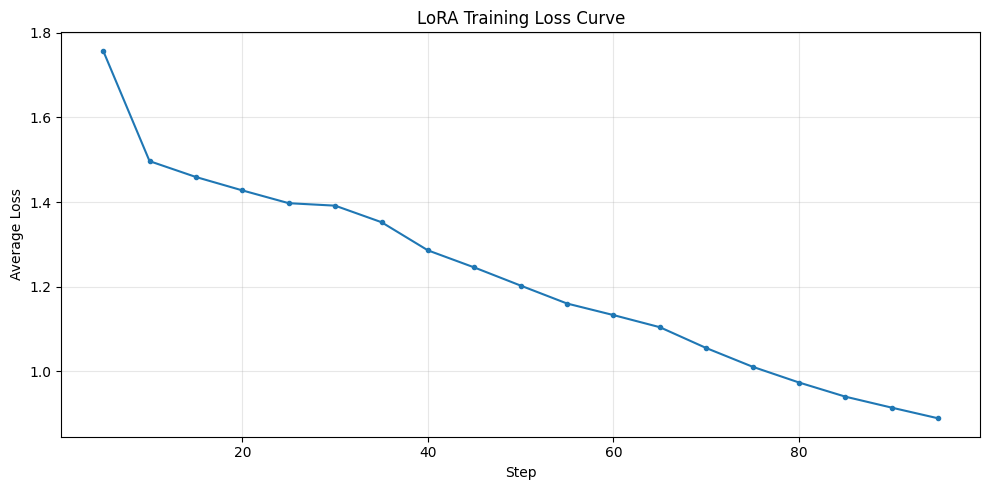

Final loss: 0.8891


In [30]:
import matplotlib.pyplot as plt

# logging_steps 已在训练代码中定义为 5，这里保持一致
steps = [(i + 1) * logging_steps for i in range(len(loss_history))]

plt.figure(figsize=(10, 5))
plt.plot(steps, loss_history, marker="o", markersize=3, linewidth=1.5)
plt.xlabel("Step")
plt.ylabel("Average Loss")
plt.title("LoRA Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final loss: {loss_history[-1]:.4f}")

## 评估

In [31]:
def inference(
    model,
    tokenizer,
    text: str, # 输入的提示文本
    max_new_tokens: int = 160, # 最多生成多少个新 token
    do_sample: bool = True, # 是否随机采样（True =多样性, False =贪婪）
    temperature: float = 0.3,
    print_inputs: bool = True,
    streaming: bool = False,
):
    # 构建输入
    prompt_msg = [
        {"role": "user", "content": text}
    ]
    prompt = tokenizer.apply_chat_template(prompt_msg, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt', add_special_tokens=False).to(device)
    input_ids = inputs['input_ids']
    im_end_id = tokenizer.encode("<|im_end|>")[0]

    # 是否打印输入部分
    if print_inputs:
        print(prompt, end='')

    # 生成
    stop_words = [tokenizer.eos_token_id, im_end_id]
    generated_tokens = []

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)

        logits = outputs.logits[:, -1, :]

        # 不同采样方式
        if do_sample:
            logits = logits / temperature
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        else:
            # 贪婪解码
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        if next_token.item() in stop_words:
            break
        generated_tokens.append(next_token.item())
        # 流式输出
        if streaming:
            yield tokenizer.decode(generated_tokens)

        # 更新输入
        input_ids = torch.cat([input_ids, next_token], dim=-1)

    generated_text = tokenizer.decode(generated_tokens)
    return generated_text

In [32]:
model.eval() # 设为评估模式，关闭训练行为

# 测试问题列表
for test_text in [
    'Describe the process of bacterial conjugation and its significance in the context of antibiotic resistance.',
    'Explain the role of insulin in the body and how insulin resistance affects blood sugar levels.',
    'Provide recommendations for lifestyle changes that can help improve the overall health of a patient with type 2 diabetes.',
]:
    print('=' * 80)
    last_text = ''
    for text in inference(model, tokenizer, test_text, streaming=True):
        cur_text = text.replace(last_text, '')
        print(cur_text, end='', flush=True)
        last_text = text
    print('\n')

<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Describe the process of bacterial conjugation and its significance in the context of antibiotic resistance.<|im_end|>
<|im_start|>assistant
Bacterial conjugation is a process by which bacteria exchange genetic material through direct cell-to-cell contact, typically involving a sex pilus. This process is significant in antibiotic resistance as it allows bacteria to exchange genetic material, increasing the chances of resistance genes being transferred to other bacteria.

<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Explain the role of insulin in the body and how insulin resistance affects blood sugar levels.<|im_end|>
<|im_start|>assistant
Insulin is a hormone produced by the pancreas that helps regulate blood sugar levels by allowing glucose (sugar) from the bloodstream to enter cells. Insulin resistance occurs when the body's cells do not respond properly to insulin, causing them to 

# 3. 消融实验（Ablation Study）

## 3.1 不同 Rank 对比

固定基础模型、数据、训练超参数和缩放系数 `alpha/r=2`，仅改变 LoRA rank：`r = 1, 2, 4, 8, 16, 32, 64`；每个 rank 对应设置 `alpha = 2 × r`。每组实验均从相同的预训练权重开始，并使用相同随机种子和数据顺序。记录训练 loss、最终验证 loss、困惑度、可训练参数量和固定问题的生成结果。

> 依次训练 7 个 0.5B 模型会产生较大计算开销；模型按 rank 串行训练，并在每组结束后释放显存。

In [38]:
import gc
import math
import random
import time
import numpy as np
import pandas as pd

rank_values = [1, 2, 4, 8, 16, 32, 64]
rank_scaling = 2
rank_seed = 42
rank_eval_bsz = bsz

rank_test_prompts = [
    'Describe the process of bacterial conjugation and its significance in the context of antibiotic resistance.',
    'Explain the role of insulin in the body and how insulin resistance affects blood sugar levels.',
]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [39]:
def evaluate_loss(model, dataloader):
    model.eval()
    loss_sum = 0.0
    valid_token_count = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            logits = model(input_ids, attention_mask=attention_mask).logits
            flat_logits = rearrange(logits, 'b s v -> (b s) v')
            flat_labels = rearrange(labels, 'b s -> (b s)')
            token_count = (flat_labels != -100).sum().item()
            batch_loss = F.cross_entropy(
                flat_logits, flat_labels, ignore_index=-100, reduction='sum'
            )
            loss_sum += batch_loss.item()
            valid_token_count += token_count
    return loss_sum / valid_token_count

def generate_answer(model, prompt, max_new_tokens=160):
    messages = [{'role': 'user', 'content': prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors='pt', add_special_tokens=False).to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            eos_token_id=[tokenizer.eos_token_id, tokenizer.encode('<|im_end|>')[0]],
            pad_token_id=tokenizer.pad_token_id,
        )
    new_tokens = output_ids[0, inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


In [40]:
rank_results = {}
eval_dataloader = DataLoader(
    ds, batch_size=rank_eval_bsz, shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, tokenizer),
)

for rank in rank_values:
    print(f'\n{"=" * 30} rank={rank} {"=" * 30}')
    set_seed(rank_seed)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    rank_model = AutoModelForCausalLM.from_pretrained(
        model_name_or_path, dtype=dtype
    ).to(device)
    rank_alpha = rank * rank_scaling
    replace_linear_with_lora(rank_model, r=rank, alpha=rank_alpha, dropout_p=0.0)
    rank_model.to(device)

    trainable_params = count_trainable_parameters(rank_model)
    rank_optimizer = optim.AdamW(
        (p for p in rank_model.parameters() if p.requires_grad), lr=lr
    )
    train_generator = torch.Generator().manual_seed(rank_seed)
    rank_dataloader = DataLoader(
        ds, batch_size=bsz, shuffle=True, generator=train_generator,
        collate_fn=lambda batch: collate_fn(batch, tokenizer),
    )

    step_losses = []
    log_steps = []
    log_losses = []
    start_time = time.perf_counter()
    rank_model.train()

    for epoch in range(num_epochs):
        progress = tqdm(rank_dataloader, desc=f'r={rank} Epoch {epoch + 1}/{num_epochs}')
        for batch in progress:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            rank_optimizer.zero_grad()
            logits = rank_model(input_ids, attention_mask=attention_mask).logits
            loss = F.cross_entropy(
                rearrange(logits, 'b s v -> (b s) v'),
                rearrange(labels, 'b s -> (b s)'),
                ignore_index=-100,
            )
            loss.backward()
            nn.utils.clip_grad_norm_(rank_model.parameters(), max_grad_norm)
            rank_optimizer.step()

            step_losses.append(loss.item())
            current_step = len(step_losses)
            if current_step % logging_steps == 0:
                window_loss = sum(step_losses[-logging_steps:]) / logging_steps
                log_steps.append(current_step)
                log_losses.append(window_loss)
                progress.set_postfix(loss=f'{window_loss:.4f}')

    train_seconds = time.perf_counter() - start_time
    final_train_loss = sum(step_losses[-len(rank_dataloader):]) / len(rank_dataloader)
    final_eval_loss = evaluate_loss(rank_model, eval_dataloader)
    answers = {prompt: generate_answer(rank_model, prompt) for prompt in rank_test_prompts}
    peak_memory_gb = (
        torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else float('nan')
    )

    rank_results[rank] = {
        'steps': log_steps,
        'loss_curve': log_losses,
        'alpha': rank_alpha,
        'scaling': rank_scaling,
        'final_train_loss': final_train_loss,
        'final_eval_loss': final_eval_loss,
        'perplexity': math.exp(min(final_eval_loss, 20)),
        'trainable_params': trainable_params,
        'train_seconds': train_seconds,
        'peak_memory_gb': peak_memory_gb,
        'answers': answers,
    }
    print(
        f'r={rank}: train_loss={final_train_loss:.4f}, eval_loss={final_eval_loss:.4f}, '
        f'ppl={rank_results[rank]["perplexity"]:.2f}, params={trainable_params:,}'
    )

    del rank_model, rank_optimizer, rank_dataloader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



============================== rank=1 ==============================


r=1 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  7.47it/s, loss=0.9766]


r=1: train_loss=1.0245, eval_loss=0.8266, ppl=2.29, params=473,088

============================== rank=2 ==============================


r=2 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  7.52it/s, loss=0.7961]


r=2: train_loss=0.8462, eval_loss=0.5926, ppl=1.81, params=946,176

============================== rank=4 ==============================


...

r=16: train_loss=0.3251, eval_loss=0.1817, ppl=1.20, params=7,569,408

============================== rank=32 ==============================


r=32 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  6.51it/s, loss=0.3684]


r=32: train_loss=0.3246, eval_loss=0.1768, ppl=1.19, params=15,138,816

============================== rank=64 ==============================


r=64 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  6.90it/s, loss=0.4020]


r=64: train_loss=0.3800, eval_loss=0.2297, ppl=1.26, params=30,277,632


### Loss 曲线与最终指标

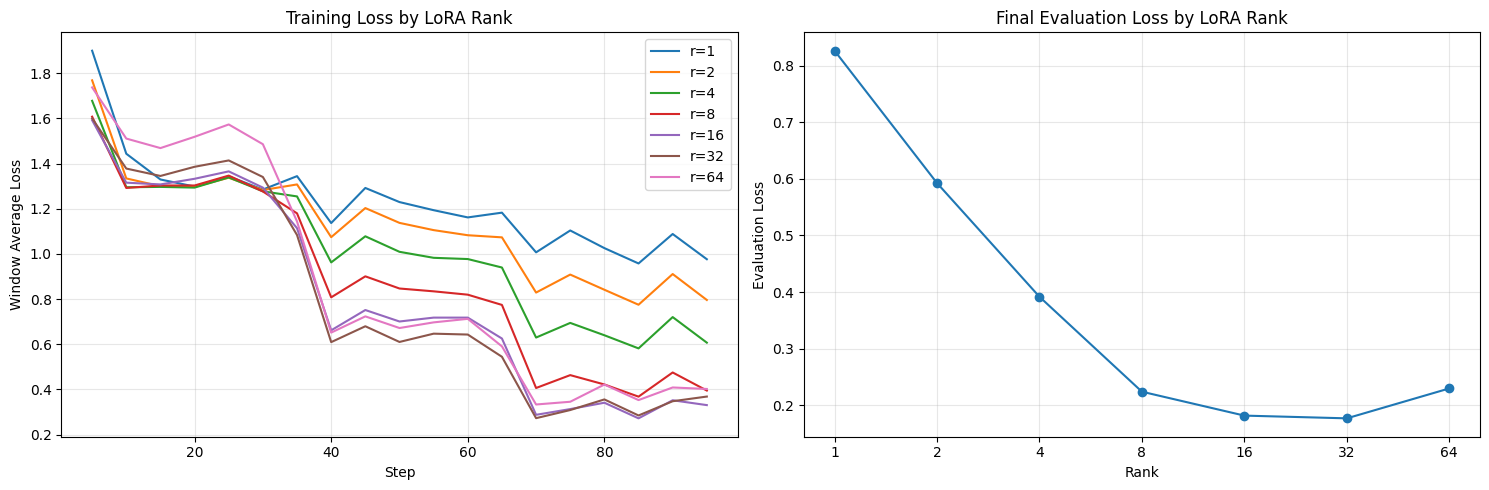

,rank,alpha,scaling(alpha/r),trainable_params,final_train_loss,final_eval_loss,perplexity,train_seconds,peak_memory_gb
0,1,2,2.0000,473088,1.0245,0.8266,2.29,13.5,7.69
1,2,4,2.0000,946176,0.8462,0.5926,1.81,13.0,7.69
2,4,8,2.0000,1892352,0.6513,0.3917,1.48,13.1,7.70
3,8,16,2.0000,3784704,0.4286,0.2239,1.25,13.5,7.71
4,16,32,2.0000,7569408,0.3251,0.1817,1.20,14.7,7.74
5,32,64,2.0000,15138816,0.3246,0.1768,1.19,14.7,7.80
6,64,128,2.0000,30277632,0.3800,0.2297,1.26,14.1,7.91


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for rank, result in rank_results.items():
    axes[0].plot(result['steps'], result['loss_curve'], label=f'r={rank}')
axes[0].set(title='Training Loss by LoRA Rank', xlabel='Step', ylabel='Window Average Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

ranks = list(rank_results)
eval_losses = [rank_results[r]['final_eval_loss'] for r in ranks]
axes[1].plot(ranks, eval_losses, marker='o')
axes[1].set_xscale('log', base=2)
axes[1].set_xticks(ranks, labels=ranks)
axes[1].set(title='Final Evaluation Loss by LoRA Rank', xlabel='Rank', ylabel='Evaluation Loss')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rank_summary = pd.DataFrame([
    {
        'rank': rank,
        'alpha': result['alpha'],
        'scaling(alpha/r)': result['scaling'],
        'trainable_params': result['trainable_params'],
        'final_train_loss': result['final_train_loss'],
        'final_eval_loss': result['final_eval_loss'],
        'perplexity': result['perplexity'],
        'train_seconds': result['train_seconds'],
        'peak_memory_gb': result['peak_memory_gb'],
    }
    for rank, result in rank_results.items()
]).sort_values('rank').reset_index(drop=True)
display(rank_summary.style.format({
    'scaling(alpha/r)': '{:.4f}',
    'final_train_loss': '{:.4f}',
    'final_eval_loss': '{:.4f}',
    'perplexity': '{:.2f}',
    'train_seconds': '{:.1f}',
    'peak_memory_gb': '{:.2f}',
}))


### 实验结论

1. 虽然 r 并非越大越好，即真实场景中还是应该选取合适大小的 r。但 r = 64 的失败并非因为太大，更可能是因为当前统一的**学习率、训练步数、初始化和正则化配置**不适合它。
    - 理论上：更大的 Rank 表达能力不会更弱，更高 Rank 可达到的最低训练 Loss 理论上不应更高，但是优化难度会更高，需要一组合适的超参数配置。
    - 但更大的 Rank 容量更强，也更容易拟合训练集中的偶然模式。任务所需的有效权重更新可能本身就是低秩的，收益通常会饱和。
        
2. 更高的 r 的 loss 下降效率更高

## 3.2 不同 Alpha 对比

固定 LoRA rank `r=8`，仅改变 `alpha = 1, 2, 4, 8, 16, 32, 64, 128`，对应缩放系数 `alpha/r = 0.125, 0.25, 0.5, 1, 2, 4, 8, 16`。每组实验从相同预训练权重开始，并使用相同随机种子、数据顺序和训练超参数，以观察缩放强度对收敛和最终效果的影响。


In [43]:
alpha_rank = 8
alpha_values = [1, 2, 4, 8, 16, 32, 64, 128]
alpha_seed = 42
alpha_eval_bsz = bsz
alpha_test_prompts = rank_test_prompts

In [44]:
alpha_results = {}
alpha_eval_dataloader = DataLoader(
    ds, batch_size=alpha_eval_bsz, shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, tokenizer),
)

for alpha in alpha_values:
    scaling = alpha / alpha_rank
    print(f'\n{"=" * 28} alpha={alpha}, scaling={scaling:g} {"=" * 28}')
    set_seed(alpha_seed)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    alpha_model = AutoModelForCausalLM.from_pretrained(
        model_name_or_path, dtype=dtype
    ).to(device)
    replace_linear_with_lora(
        alpha_model, r=alpha_rank, alpha=alpha, dropout_p=0.0
    )
    alpha_model.to(device)

    trainable_params = count_trainable_parameters(alpha_model)
    alpha_optimizer = optim.AdamW(
        (p for p in alpha_model.parameters() if p.requires_grad), lr=lr
    )
    train_generator = torch.Generator().manual_seed(alpha_seed)
    alpha_dataloader = DataLoader(
        ds, batch_size=bsz, shuffle=True, generator=train_generator,
        collate_fn=lambda batch: collate_fn(batch, tokenizer),
    )

    step_losses = []
    log_steps = []
    log_losses = []
    start_time = time.perf_counter()
    alpha_model.train()

    for epoch in range(num_epochs):
        progress = tqdm(
            alpha_dataloader,
            desc=f'alpha={alpha} Epoch {epoch + 1}/{num_epochs}',
        )
        for batch in progress:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            alpha_optimizer.zero_grad()
            logits = alpha_model(
                input_ids, attention_mask=attention_mask
            ).logits
            loss = F.cross_entropy(
                rearrange(logits, 'b s v -> (b s) v'),
                rearrange(labels, 'b s -> (b s)'),
                ignore_index=-100,
            )
            loss.backward()
            nn.utils.clip_grad_norm_(alpha_model.parameters(), max_grad_norm)
            alpha_optimizer.step()

            step_losses.append(loss.item())
            current_step = len(step_losses)
            if current_step % logging_steps == 0:
                window_loss = sum(step_losses[-logging_steps:]) / logging_steps
                log_steps.append(current_step)
                log_losses.append(window_loss)
                progress.set_postfix(loss=f'{window_loss:.4f}')

    train_seconds = time.perf_counter() - start_time
    final_train_loss = sum(step_losses[-len(alpha_dataloader):]) / len(alpha_dataloader)
    final_eval_loss = evaluate_loss(alpha_model, alpha_eval_dataloader)
    answers = {
        prompt: generate_answer(alpha_model, prompt)
        for prompt in alpha_test_prompts
    }
    peak_memory_gb = (
        torch.cuda.max_memory_allocated() / 1024**3
        if torch.cuda.is_available() else float('nan')
    )

    alpha_results[alpha] = {
        'steps': log_steps,
        'loss_curve': log_losses,
        'rank': alpha_rank,
        'scaling': scaling,
        'final_train_loss': final_train_loss,
        'final_eval_loss': final_eval_loss,
        'perplexity': math.exp(min(final_eval_loss, 20)),
        'trainable_params': trainable_params,
        'train_seconds': train_seconds,
        'peak_memory_gb': peak_memory_gb,
        'answers': answers,
    }
    print(
        f'alpha={alpha}, scaling={scaling:g}: '
        f'train_loss={final_train_loss:.4f}, '
        f'eval_loss={final_eval_loss:.4f}, '
        f'ppl={alpha_results[alpha]["perplexity"]:.2f}'
    )

    del alpha_model, alpha_optimizer, alpha_dataloader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



============================ alpha=1, scaling=0.125 ============================


alpha=1 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  7.24it/s, loss=1.0984]


alpha=1, scaling=0.125: train_loss=1.1478, eval_loss=1.0277, ppl=2.79

============================ alpha=2, scaling=0.25 ============================


alpha=2 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  7.42it/s, loss=0.9906]


alpha=2, scaling=0.25: train_loss=1.0385, eval_loss=0.8376, ppl=2.31

============================ alpha=4, scaling=0.5 ============================


...

alpha=32, scaling=4: train_loss=0.3266, eval_loss=0.1792, ppl=1.20

============================ alpha=64, scaling=8 ============================


alpha=64 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  7.42it/s, loss=0.3488]


alpha=64, scaling=8: train_loss=0.3353, eval_loss=0.1833, ppl=1.20

============================ alpha=128, scaling=16 ============================


alpha=128 Epoch 3/3: 100%|██████████| 32/32 [00:04<00:00,  7.30it/s, loss=0.5437]


alpha=128, scaling=16: train_loss=0.4553, eval_loss=0.2658, ppl=1.30


### Loss 曲线与最终指标


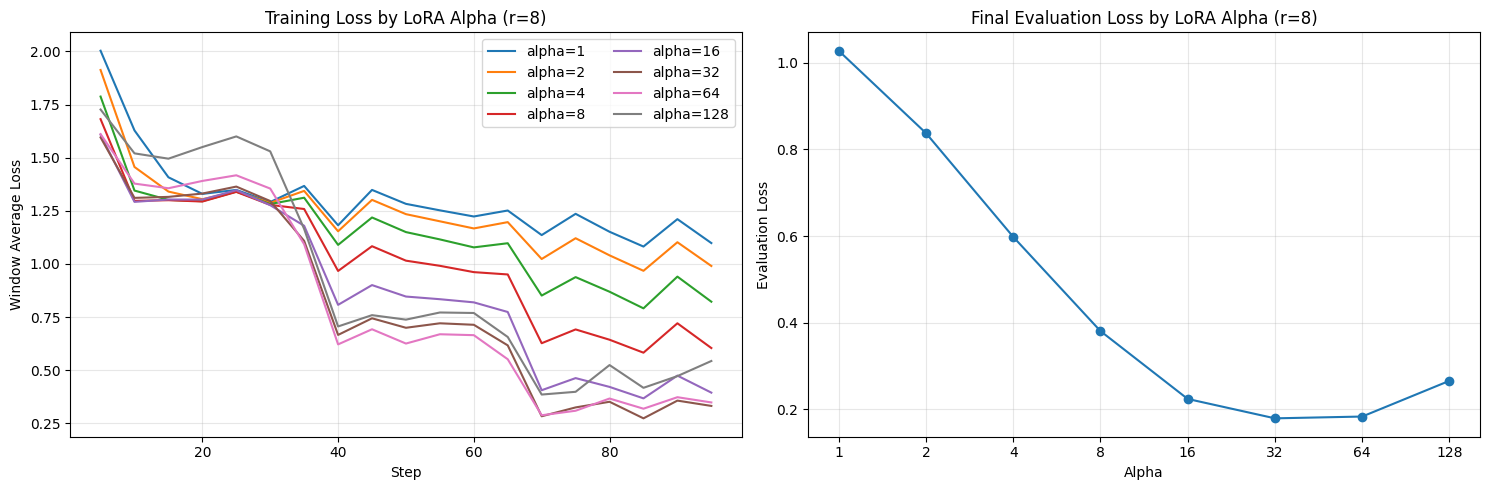

,rank,alpha,scaling(alpha/r),trainable_params,final_train_loss,final_eval_loss,perplexity,train_seconds,peak_memory_gb
0,8,1,0.1250,3784704,1.1478,1.0277,2.79,13.3,7.71
1,8,2,0.2500,3784704,1.0385,0.8376,2.31,13.0,7.71
2,8,4,0.5000,3784704,0.8710,0.5981,1.82,12.9,7.71
3,8,8,1.0000,3784704,0.6514,0.3806,1.46,13.1,7.71
4,8,16,2.0000,3784704,0.4286,0.2239,1.25,13.2,7.71
5,8,32,4.0000,3784704,0.3266,0.1792,1.20,13.0,7.71
6,8,64,8.0000,3784704,0.3353,0.1833,1.20,13.2,7.71
7,8,128,16.0000,3784704,0.4553,0.2658,1.30,13.3,7.71


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for alpha, result in alpha_results.items():
    axes[0].plot(
        result['steps'], result['loss_curve'], label=f'alpha={alpha}'
    )
axes[0].set(
    title='Training Loss by LoRA Alpha (r=8)',
    xlabel='Step',
    ylabel='Window Average Loss',
)
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=2)

alphas = list(alpha_results)
eval_losses = [alpha_results[a]['final_eval_loss'] for a in alphas]
axes[1].plot(alphas, eval_losses, marker='o')
axes[1].set_xscale('log', base=2)
axes[1].set_xticks(alphas, labels=alphas)
axes[1].set(
    title='Final Evaluation Loss by LoRA Alpha (r=8)',
    xlabel='Alpha',
    ylabel='Evaluation Loss',
)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

alpha_summary = pd.DataFrame([
    {
        'rank': result['rank'],
        'alpha': alpha,
        'scaling(alpha/r)': result['scaling'],
        'trainable_params': result['trainable_params'],
        'final_train_loss': result['final_train_loss'],
        'final_eval_loss': result['final_eval_loss'],
        'perplexity': result['perplexity'],
        'train_seconds': result['train_seconds'],
        'peak_memory_gb': result['peak_memory_gb'],
    }
    for alpha, result in alpha_results.items()
]).sort_values('alpha').reset_index(drop=True)
display(alpha_summary.style.format({
    'scaling(alpha/r)': '{:.4f}',
    'final_train_loss': '{:.4f}',
    'final_eval_loss': '{:.4f}',
    'perplexity': '{:.2f}',
    'train_seconds': '{:.1f}',
    'peak_memory_gb': '{:.2f}',
}))


### 实验结论

1. $\alpha$ 直接影响的是 $scaling = \alpha / r$，即 $\alpha$ 控制的是 “学到的更新以多大强度作用于模型”。
2. $\alpha$ 增大能加速有效学习，但不是越大越好。
3. $\alpha$ 和学习率都能影响训练强度，但它们不是同一个概念：
    - 学习率控制参数本身每一步如何变化
    $$A_{t+1} = A_t - \eta \nabla_A L$$
    $$B_{t+1} = B_t - \eta \nabla_B L$$
    - $\alpha$ 控制 BA 注入模型输出时的强度
    $$y = W_0 x + \frac{\alpha}{r} BAx$$

## 3.3 不同 Target Module 对比

固定 `r=8`、`alpha=32`（`alpha/r=4`）及其他训练条件，对比三种 LoRA 注入范围：Attention 的 Q/K/V 投影、所有线性层（不含 `lm_head`）、仅 MLP 的 gate/up/down 投影。未注入 LoRA 的参数全部冻结，以确保各组只有 LoRA 参数参与训练。


In [47]:
target_rank = 8
target_alpha = 32
target_seed = 42
target_eval_bsz = bsz
target_test_prompts = rank_test_prompts

target_module_groups = {
    'attention_qkv': {'q_proj', 'k_proj', 'v_proj'},
    'all_linear': None,
    'mlp_only': {'gate_proj', 'up_proj', 'down_proj'},
}

def replace_target_modules_with_lora(
    module, target_modules, r, alpha, dropout_p=0.0
):
    # 先冻结基础模型，未命中的线性层不能参与全量训练
    for param in module.parameters():
        param.requires_grad = False

    def replace(current_module):
        for name, child in current_module.named_children():
            if isinstance(child, nn.Linear):
                should_replace = (
                    name != 'lm_head'
                    and (target_modules is None or name in target_modules)
                )
                if should_replace:
                    setattr(
                        current_module,
                        name,
                        LoraLinear(
                            child, r=r, alpha=alpha,
                            dropout_p=dropout_p,
                        ),
                    )
            else:
                replace(child)

    replace(module)


def get_adapted_module_names(model):
    return [
        name for name, child in model.named_modules()
        if isinstance(child, LoraLinear)
    ]


In [48]:
target_results = {}
target_eval_dataloader = DataLoader(
    ds, batch_size=target_eval_bsz, shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, tokenizer),
)

for group_name, target_modules in target_module_groups.items():
    print(f'\n{"=" * 24} target={group_name} {"=" * 24}')
    set_seed(target_seed)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    target_model = AutoModelForCausalLM.from_pretrained(
        model_name_or_path, dtype=dtype
    ).to(device)
    replace_target_modules_with_lora(
        target_model,
        target_modules=target_modules,
        r=target_rank,
        alpha=target_alpha,
        dropout_p=0.0,
    )
    target_model.to(device)

    adapted_modules = get_adapted_module_names(target_model)
    trainable_params = count_trainable_parameters(target_model)
    assert trainable_params > 0, f'{group_name} 没有匹配到目标模块'
    assert all(
        'lora_A' in name or 'lora_B' in name
        for name, param in target_model.named_parameters()
        if param.requires_grad
    ), '存在 LoRA 之外的可训练参数'

    print(f'注入层数：{len(adapted_modules)}')
    print(f'可训练参数：{trainable_params:,}')
    print('前 8 个目标层：', adapted_modules[:8])

    target_optimizer = optim.AdamW(
        (p for p in target_model.parameters() if p.requires_grad), lr=lr
    )
    train_generator = torch.Generator().manual_seed(target_seed)
    target_dataloader = DataLoader(
        ds, batch_size=bsz, shuffle=True, generator=train_generator,
        collate_fn=lambda batch: collate_fn(batch, tokenizer),
    )

    step_losses = []
    log_steps = []
    log_losses = []
    start_time = time.perf_counter()
    target_model.train()

    for epoch in range(num_epochs):
        progress = tqdm(
            target_dataloader,
            desc=f'{group_name} Epoch {epoch + 1}/{num_epochs}',
        )
        for batch in progress:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            target_optimizer.zero_grad()
            logits = target_model(
                input_ids, attention_mask=attention_mask
            ).logits
            loss = F.cross_entropy(
                rearrange(logits, 'b s v -> (b s) v'),
                rearrange(labels, 'b s -> (b s)'),
                ignore_index=-100,
            )
            loss.backward()
            nn.utils.clip_grad_norm_(target_model.parameters(), max_grad_norm)
            target_optimizer.step()

            step_losses.append(loss.item())
            current_step = len(step_losses)
            if current_step % logging_steps == 0:
                window_loss = sum(step_losses[-logging_steps:]) / logging_steps
                log_steps.append(current_step)
                log_losses.append(window_loss)
                progress.set_postfix(loss=f'{window_loss:.4f}')

    train_seconds = time.perf_counter() - start_time
    final_train_loss = sum(
        step_losses[-len(target_dataloader):]
    ) / len(target_dataloader)
    final_eval_loss = evaluate_loss(target_model, target_eval_dataloader)
    answers = {
        prompt: generate_answer(target_model, prompt)
        for prompt in target_test_prompts
    }
    peak_memory_gb = (
        torch.cuda.max_memory_allocated() / 1024**3
        if torch.cuda.is_available() else float('nan')
    )

    target_results[group_name] = {
        'steps': log_steps,
        'loss_curve': log_losses,
        'rank': target_rank,
        'alpha': target_alpha,
        'scaling': target_alpha / target_rank,
        'adapted_module_count': len(adapted_modules),
        'adapted_modules': adapted_modules,
        'trainable_params': trainable_params,
        'final_train_loss': final_train_loss,
        'final_eval_loss': final_eval_loss,
        'perplexity': math.exp(min(final_eval_loss, 20)),
        'train_seconds': train_seconds,
        'peak_memory_gb': peak_memory_gb,
        'answers': answers,
    }
    print(
        f'{group_name}: train_loss={final_train_loss:.4f}, '
        f'eval_loss={final_eval_loss:.4f}, '
        f'ppl={target_results[group_name]["perplexity"]:.2f}'
    )

    del target_model, target_optimizer, target_dataloader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



======================== target=attention_qkv ========================


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 4853.69it/s]


注入层数：72
可训练参数：1,179,648
前 8 个目标层： ['model.layers.0.self_attn.q_proj', 'model.layers.0.self_attn.k_proj', 'model.layers.0.self_attn.v_proj', 'model.layers.1.self_attn.q_proj', 'model.layers.1.self_attn.k_proj', 'model.layers.1.self_attn.v_proj', 'model.layers.2.self_attn.q_proj', 'model.layers.2.self_attn.k_proj']


attention_qkv Epoch 3/3: 100%|██████████| 32/32 [00:03<00:00,  9.80it/s, loss=0.7406]


attention_qkv: train_loss=0.7788, eval_loss=0.5551, ppl=1.74

======================== target=all_linear ========================


...

all_linear: train_loss=0.3266, eval_loss=0.1792, ppl=1.20

======================== target=mlp_only ========================


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 4813.89it/s]


注入层数：72
可训练参数：2,211,840
前 8 个目标层： ['model.layers.0.mlp.gate_proj', 'model.layers.0.mlp.up_proj', 'model.layers.0.mlp.down_proj', 'model.layers.1.mlp.gate_proj', 'model.layers.1.mlp.up_proj', 'model.layers.1.mlp.down_proj', 'model.layers.2.mlp.gate_proj', 'model.layers.2.mlp.up_proj']


mlp_only Epoch 3/3: 100%|██████████| 32/32 [00:03<00:00, 10.43it/s, loss=0.3523]


mlp_only: train_loss=0.3667, eval_loss=0.1923, ppl=1.21


### Loss 曲线与最终指标


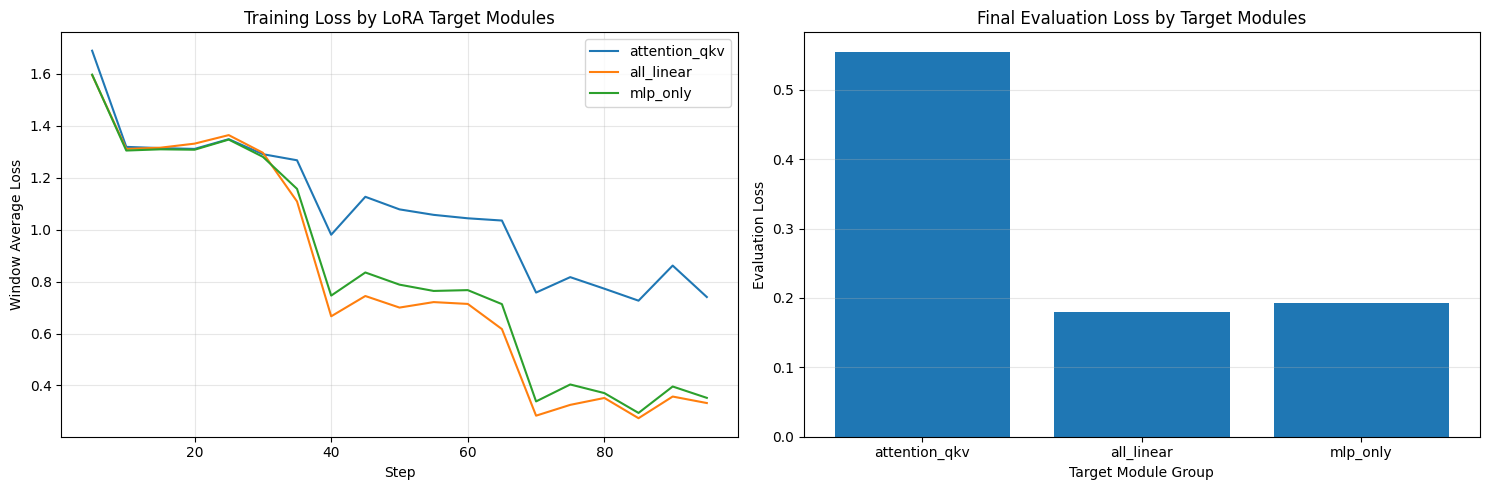

,target_group,target_modules,adapted_module_count,rank,alpha,scaling(alpha/r),trainable_params,final_train_loss,final_eval_loss,perplexity,train_seconds,peak_memory_gb
0,all_linear,all nn.Linear except lm_head,168,8,32,4.0000,3784704,0.3266,0.1792,1.20,13.2,7.71
1,mlp_only,"down_proj, gate_proj, up_proj",72,8,32,4.0000,2211840,0.3667,0.1923,1.21,9.3,7.55
2,attention_qkv,"k_proj, q_proj, v_proj",72,8,32,4.0000,1179648,0.7788,0.5551,1.74,9.9,7.23


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for group_name, result in target_results.items():
    axes[0].plot(
        result['steps'], result['loss_curve'], label=group_name
    )
axes[0].set(
    title='Training Loss by LoRA Target Modules',
    xlabel='Step',
    ylabel='Window Average Loss',
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

group_names = list(target_results)
eval_losses = [
    target_results[name]['final_eval_loss'] for name in group_names
]
axes[1].bar(group_names, eval_losses)
axes[1].set(
    title='Final Evaluation Loss by Target Modules',
    xlabel='Target Module Group',
    ylabel='Evaluation Loss',
)
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

target_summary = pd.DataFrame([
    {
        'target_group': group_name,
        'target_modules': (
            'all nn.Linear except lm_head'
            if target_module_groups[group_name] is None
            else ', '.join(sorted(target_module_groups[group_name]))
        ),
        'adapted_module_count': result['adapted_module_count'],
        'rank': result['rank'],
        'alpha': result['alpha'],
        'scaling(alpha/r)': result['scaling'],
        'trainable_params': result['trainable_params'],
        'final_train_loss': result['final_train_loss'],
        'final_eval_loss': result['final_eval_loss'],
        'perplexity': result['perplexity'],
        'train_seconds': result['train_seconds'],
        'peak_memory_gb': result['peak_memory_gb'],
    }
    for group_name, result in target_results.items()
]).sort_values('final_eval_loss').reset_index(drop=True)
display(target_summary.style.format({
    'scaling(alpha/r)': '{:.4f}',
    'final_train_loss': '{:.4f}',
    'final_eval_loss': '{:.4f}',
    'perplexity': '{:.2f}',
    'train_seconds': '{:.1f}',
    'peak_memory_gb': '{:.2f}',
}))


### 实验结论

> 全线性层 = attention层 + MLP层

**LoRA 安装位置的不同会影响 Loss** <br>
- 只给 attention 层安装 LoRA 只能改变：
    - Token 关注哪些 Token；
    - 不同 Token 之间如何匹配；
    - Attention 传递哪些信息。
- 只给 MLP 层安装 LoRA 只能改变：
    - 哪些特征被激活；
    - 特征如何组合；
    - Attention 输出如何被非线性处理；
    - 如何把已有知识转化为任务需要的表达。
- 给全部线性层加 LoRA：
    - 模型既能调整 Attention，也能调整 MLP，修改空间最大，因此达到最低 Loss。


## 3.4 LoRA vs Full Fine-tuning（Tiny LLaMA）

在相同 Tiny LLaMA 初始权重、合成训练/验证数据、优化器、学习率、批大小和训练轮数下，对比：
- **Full Fine-tuning**：更新模型全部参数；
- **LoRA**：冻结基础模型，仅在 Transformer Block 的全部 Attention/MLP 线性层注入 LoRA，排除 `lm_head`。

本实验记录训练/验证 Loss、可训练参数比例、训练耗时、峰值显存和可训练权重大小。合成任务要求模型预测固定步长的循环整数序列，验证集使用不同起点但遵循相同规律。


In [51]:
tiny_compare_seed = 42
tiny_train_size = 512
tiny_eval_size = 128
tiny_seq_len = 24
tiny_batch_size = 32
tiny_num_epochs = 10
tiny_lr = 1e-3
tiny_logging_steps = 5
tiny_lora_rank = 8
tiny_lora_alpha = 32

class TinySequenceDataset(Dataset):
    def __init__(self, size, seq_len, vocab_size, seed):
        generator = torch.Generator().manual_seed(seed)
        starts = torch.randint(0, vocab_size, (size,), generator=generator)
        strides = torch.randint(1, 8, (size,), generator=generator)
        positions = torch.arange(seq_len + 1)
        sequences = (
            starts[:, None] + strides[:, None] * positions[None, :]
        ) % vocab_size
        self.input_ids = sequences[:, :-1].long()
        self.labels = sequences[:, 1:].long()

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, index):
        return {
            'input_ids': self.input_ids[index],
            'labels': self.labels[index],
        }


tiny_train_ds = TinySequenceDataset(
    tiny_train_size, tiny_seq_len, config.vocab_size, tiny_compare_seed
)
tiny_eval_ds = TinySequenceDataset(
    tiny_eval_size, tiny_seq_len, config.vocab_size, tiny_compare_seed + 1
)

tiny_compare_config = copy.deepcopy(config)
tiny_compare_config.tie_word_embeddings = False
set_seed(tiny_compare_seed)
tiny_initial_model = AutoModelForCausalLM.from_config(tiny_compare_config)
tiny_initial_state = {
    name: tensor.detach().cpu().clone()
    for name, tensor in tiny_initial_model.state_dict().items()
}
del tiny_initial_model

print(f'训练样本：{len(tiny_train_ds)}，验证样本：{len(tiny_eval_ds)}')
print(f'序列长度：{tiny_seq_len}，词表大小：{config.vocab_size}')


训练样本：512，验证样本：128
序列长度：24，词表大小：128


In [52]:
def evaluate_tiny_causal_lm(model, dataloader):
    model.eval()
    loss_sum = 0.0
    token_count = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            logits = model(input_ids).logits
            loss_sum += F.cross_entropy(
                rearrange(logits, 'b s v -> (b s) v'),
                rearrange(labels, 'b s -> (b s)'),
                reduction='sum',
            ).item()
            token_count += labels.numel()
    return loss_sum / token_count


def train_tiny_method(method_name):
    set_seed(tiny_compare_seed)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    model = AutoModelForCausalLM.from_config(tiny_compare_config)
    model.load_state_dict(tiny_initial_state)

    if method_name == 'LoRA':
        replace_target_modules_with_lora(
            model,
            target_modules=None,
            r=tiny_lora_rank,
            alpha=tiny_lora_alpha,
            dropout_p=0.0,
        )
    elif method_name != 'Full Fine-tuning':
        raise ValueError(f'未知方法：{method_name}')

    model.to(device)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = count_trainable_parameters(model)
    trainable_bytes = sum(
        p.numel() * p.element_size()
        for p in model.parameters() if p.requires_grad
    )
    optimizer = optim.AdamW(
        (p for p in model.parameters() if p.requires_grad), lr=tiny_lr
    )
    generator = torch.Generator().manual_seed(tiny_compare_seed)
    train_loader = DataLoader(
        tiny_train_ds, batch_size=tiny_batch_size,
        shuffle=True, generator=generator,
    )
    eval_loader = DataLoader(
        tiny_eval_ds, batch_size=tiny_batch_size, shuffle=False
    )

    step_losses = []
    log_steps = []
    log_losses = []
    start_time = time.perf_counter()
    model.train()

    for epoch in range(tiny_num_epochs):
        progress = tqdm(
            train_loader,
            desc=f'{method_name} Epoch {epoch + 1}/{tiny_num_epochs}',
        )
        for batch in progress:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids).logits
            loss = F.cross_entropy(
                rearrange(logits, 'b s v -> (b s) v'),
                rearrange(labels, 'b s -> (b s)'),
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            step_losses.append(loss.item())
            current_step = len(step_losses)
            if current_step % tiny_logging_steps == 0:
                window_loss = sum(
                    step_losses[-tiny_logging_steps:]
                ) / tiny_logging_steps
                log_steps.append(current_step)
                log_losses.append(window_loss)
                progress.set_postfix(loss=f'{window_loss:.4f}')

    train_seconds = time.perf_counter() - start_time
    final_train_loss = sum(step_losses[-len(train_loader):]) / len(train_loader)
    final_eval_loss = evaluate_tiny_causal_lm(model, eval_loader)
    peak_memory_gb = (
        torch.cuda.max_memory_allocated() / 1024**3
        if torch.cuda.is_available() else float('nan')
    )

    result = {
        'steps': log_steps,
        'loss_curve': log_losses,
        'total_params': total_params,
        'trainable_params': trainable_params,
        'trainable_ratio': trainable_params / total_params,
        'trainable_size_kb': trainable_bytes / 1024,
        'final_train_loss': final_train_loss,
        'final_eval_loss': final_eval_loss,
        'perplexity': math.exp(min(final_eval_loss, 20)),
        'train_seconds': train_seconds,
        'peak_memory_gb': peak_memory_gb,
    }

    del model, optimizer, train_loader, eval_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


In [53]:
tiny_compare_results = {}
for method_name in ['Full Fine-tuning', 'LoRA']:
    print(f'\n{"=" * 28} {method_name} {"=" * 28}')
    tiny_compare_results[method_name] = train_tiny_method(method_name)
    result = tiny_compare_results[method_name]
    print(
        f'{method_name}: train_loss={result["final_train_loss"]:.4f}, '
        f'eval_loss={result["final_eval_loss"]:.4f}, '
        f'trainable={result["trainable_params"]:,} '
        f'({result["trainable_ratio"]:.2%})'
    )



============================ Full Fine-tuning ============================


Full Fine-tuning Epoch 10/10: 100%|██████████| 16/16 [00:00<00:00, 42.55it/s, loss=2.1684]


Full Fine-tuning: train_loss=2.2325, eval_loss=2.1774, trainable=40,920 (100.00%)

============================ LoRA ============================


LoRA Epoch 10/10: 100%|██████████| 16/16 [00:00<00:00, 31.47it/s, loss=4.6493]


LoRA: train_loss=4.6511, eval_loss=4.6643, trainable=16,896 (29.22%)


### 效果与效率对比


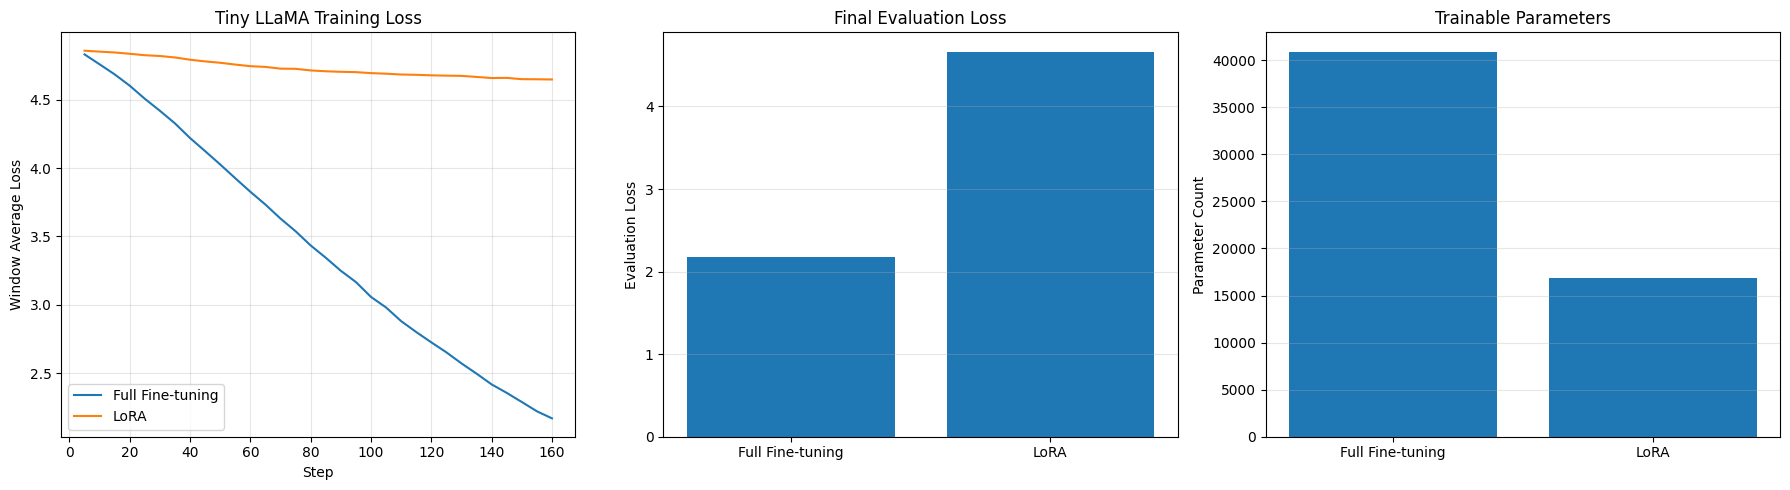

,method,total_params,trainable_params,trainable_ratio,trainable_size_kb,final_train_loss,final_eval_loss,perplexity,train_seconds,peak_memory_gb
0,Full Fine-tuning,40920,40920,100.00%,159.84,2.2325,2.1774,8.82,3.927,1.2902
1,LoRA,57816,16896,29.22%,66.00,4.6511,4.6643,106.09,5.256,1.2899


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for method_name, result in tiny_compare_results.items():
    axes[0].plot(
        result['steps'], result['loss_curve'], label=method_name
    )
axes[0].set(
    title='Tiny LLaMA Training Loss',
    xlabel='Step', ylabel='Window Average Loss',
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

method_names = list(tiny_compare_results)
axes[1].bar(
    method_names,
    [tiny_compare_results[name]['final_eval_loss'] for name in method_names],
)
axes[1].set(title='Final Evaluation Loss', ylabel='Evaluation Loss')
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(
    method_names,
    [tiny_compare_results[name]['trainable_params'] for name in method_names],
)
axes[2].set(title='Trainable Parameters', ylabel='Parameter Count')
axes[2].ticklabel_format(axis='y', style='plain')
axes[2].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

tiny_compare_summary = pd.DataFrame([
    {
        'method': method_name,
        'total_params': result['total_params'],
        'trainable_params': result['trainable_params'],
        'trainable_ratio': result['trainable_ratio'],
        'trainable_size_kb': result['trainable_size_kb'],
        'final_train_loss': result['final_train_loss'],
        'final_eval_loss': result['final_eval_loss'],
        'perplexity': result['perplexity'],
        'train_seconds': result['train_seconds'],
        'peak_memory_gb': result['peak_memory_gb'],
    }
    for method_name, result in tiny_compare_results.items()
]).sort_values('final_eval_loss').reset_index(drop=True)
display(tiny_compare_summary.style.format({
    'trainable_ratio': '{:.2%}',
    'trainable_size_kb': '{:.2f}',
    'final_train_loss': '{:.4f}',
    'final_eval_loss': '{:.4f}',
    'perplexity': '{:.2f}',
    'train_seconds': '{:.3f}',
    'peak_memory_gb': '{:.4f}',
}))


### 实验结论

- Full Fine-tuning 的可训练空间更大，通常更容易在同样步数下达到较低 Loss，但需要保存和优化全部参数。
- LoRA 只训练低秩增量，参数、优化器状态和 Adapter 存储成本显著更低；代价是更新空间受 Rank 和 Target Modules 限制。
- Tiny 模型本身很小，固定开销和 LoRA 额外矩阵乘法会弱化 LoRA 的速度/显存优势；LoRA 的主要优势在大模型上更明显。


# 4. LoRA 权重分析

重新训练一个 `r=8, alpha=32` 的 all-linear LoRA Adapter，并分析各层学到的有效更新：
$$\Delta W = \frac{\alpha}{r}BA$$

- **奇异值**：LoRA 学到的权重变化，主要集中在多少个方向上；
- **层间差异**：比较 $\|\Delta W\|_F$ 和相对更新强度 $\|\Delta W\|_F / \|W_0\|_F$；
- **方向相似度**：计算 $\mathrm{cosine}(W_0, \Delta W)$，判断更新更偏向增强原方向还是引入新方向。

> 为避免构造与原权重同样大的完整 `ΔW`，SVD 使用低秩 QR 分解转化为 `r × r` 小矩阵计算，数学上与直接对 `B @ A` 做 SVD 等价。


In [55]:
analysis_rank = 8
analysis_alpha = 32
analysis_seed = 42

set_seed(analysis_seed)
if torch.cuda.is_available():
    torch.cuda.empty_cache()

analysis_model = AutoModelForCausalLM.from_pretrained(
    model_name_or_path, dtype=dtype
).to(device)
replace_target_modules_with_lora(
    analysis_model,
    target_modules=None,
    r=analysis_rank,
    alpha=analysis_alpha,
    dropout_p=0.0,
)
analysis_model.to(device)

analysis_optimizer = optim.AdamW(
    (p for p in analysis_model.parameters() if p.requires_grad), lr=lr
)
analysis_generator = torch.Generator().manual_seed(analysis_seed)
analysis_dataloader = DataLoader(
    ds, batch_size=bsz, shuffle=True, generator=analysis_generator,
    collate_fn=lambda batch: collate_fn(batch, tokenizer),
)

analysis_loss_history = []
analysis_model.train()
for epoch in range(num_epochs):
    progress = tqdm(
        analysis_dataloader,
        desc=f'Weight analysis Epoch {epoch + 1}/{num_epochs}',
    )
    for batch in progress:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        analysis_optimizer.zero_grad()
        logits = analysis_model(
            input_ids, attention_mask=attention_mask
        ).logits
        loss = F.cross_entropy(
            rearrange(logits, 'b s v -> (b s) v'),
            rearrange(labels, 'b s -> (b s)'),
            ignore_index=-100,
        )
        loss.backward()
        nn.utils.clip_grad_norm_(analysis_model.parameters(), max_grad_norm)
        analysis_optimizer.step()
        analysis_loss_history.append(loss.item())
        progress.set_postfix(loss=f'{loss.item():.4f}')

analysis_model.eval()
print(f'最终训练 batch loss：{analysis_loss_history[-1]:.4f}')
print(f'待分析 LoRA 层数：{len(get_adapted_module_names(analysis_model))}')


Weight analysis Epoch 3/3: 100%|██████████| 32/32 [00:05<00:00,  6.34it/s, loss=0.4199]

最终训练 batch loss：0.4199
待分析 LoRA 层数：168


In [56]:
attention_projections = {'q_proj', 'k_proj', 'v_proj', 'o_proj'}
mlp_projections = {'gate_proj', 'up_proj', 'down_proj'}


def low_rank_singular_values(lora_B, lora_A):
    # B @ A = Q_B @ (R_B @ R_A.T) @ Q_A.T；非零奇异值来自中间 r×r 矩阵
    q_b, r_b = torch.linalg.qr(lora_B, mode='reduced')
    q_a, r_a = torch.linalg.qr(lora_A.T, mode='reduced')
    del q_b, q_a
    return torch.linalg.svdvals(r_b @ r_a.T)


def energy_rank(singular_values, threshold):
    energy = singular_values.square()
    total = energy.sum()
    if total <= 0:
        return 0
    cumulative = torch.cumsum(energy, dim=0) / total
    return int(
        torch.searchsorted(
            cumulative, torch.tensor(threshold, device=cumulative.device)
        ).item() + 1
    )


def parse_lora_layer(name):
    parts = name.split('.')
    projection = parts[-1]
    layer_index = (
        int(parts[parts.index('layers') + 1])
        if 'layers' in parts else -1
    )
    if projection in attention_projections:
        module_group = 'attention'
    elif projection in mlp_projections:
        module_group = 'mlp'
    else:
        module_group = 'other'
    return layer_index, projection, module_group


analysis_records = []
analysis_spectra = []
with torch.no_grad():
    for name, module in analysis_model.named_modules():
        if not isinstance(module, LoraLinear):
            continue

        weight = module.base_layer.weight.detach().float()
        lora_A = module.lora_A.detach().float()
        lora_B = module.lora_B.detach().float()
        scaling = float(module.alpha) / float(module.r)

        singular_values = low_rank_singular_values(lora_B, lora_A) * scaling
        delta_norm = torch.linalg.vector_norm(singular_values).item()
        weight_norm = torch.linalg.vector_norm(weight).item()

        # <W0, BA> = <W0.T @ B, A.T>，不显式构造大型 BA
        inner_product = (
            (weight.T @ lora_B) * lora_A.T
        ).sum().item() * scaling
        cosine = inner_product / max(weight_norm * delta_norm, 1e-12)
        spectral_norm = singular_values.max().item()
        stable_rank = (
            delta_norm**2 / max(spectral_norm**2, 1e-24)
        )
        numerical_rank = int(
            (singular_values > singular_values.max() * 1e-5).sum().item()
        )
        layer_index, projection, module_group = parse_lora_layer(name)

        analysis_records.append({
            'layer_name': name,
            'layer_index': layer_index,
            'projection': projection,
            'module_group': module_group,
            'rank_r': module.r,
            'effective_rank_90': energy_rank(singular_values, 0.90),
            'effective_rank_99': energy_rank(singular_values, 0.99),
            'numerical_rank': numerical_rank,
            'stable_rank': stable_rank,
            'delta_fro_norm': delta_norm,
            'base_fro_norm': weight_norm,
            'relative_update': delta_norm / max(weight_norm, 1e-12),
            'cosine_w0_delta': cosine,
        })
        for index, value in enumerate(singular_values.cpu().tolist(), start=1):
            analysis_spectra.append({
                'layer_name': name,
                'layer_index': layer_index,
                'projection': projection,
                'module_group': module_group,
                'singular_index': index,
                'singular_value': value,
                'normalized_singular_value': (
                    value / max(singular_values[0].item(), 1e-12)
                ),
            })

weight_analysis_df = pd.DataFrame(analysis_records)
singular_spectra_df = pd.DataFrame(analysis_spectra)

weight_analysis_summary = (
    weight_analysis_df.groupby('module_group')
    .agg(
        layer_count=('layer_name', 'count'),
        mean_effective_rank_90=('effective_rank_90', 'mean'),
        mean_effective_rank_99=('effective_rank_99', 'mean'),
        mean_stable_rank=('stable_rank', 'mean'),
        mean_delta_norm=('delta_fro_norm', 'mean'),
        mean_relative_update=('relative_update', 'mean'),
        mean_abs_cosine=('cosine_w0_delta', lambda x: x.abs().mean()),
        mean_cosine=('cosine_w0_delta', 'mean'),
    )
    .reset_index()
)
display(weight_analysis_summary.style.format({
    'mean_effective_rank_90': '{:.2f}',
    'mean_effective_rank_99': '{:.2f}',
    'mean_stable_rank': '{:.2f}',
    'mean_delta_norm': '{:.4f}',
    'mean_relative_update': '{:.4%}',
    'mean_abs_cosine': '{:.4f}',
    'mean_cosine': '{:.4f}',
}))


,module_group,layer_count,mean_effective_rank_90,mean_effective_rank_99,mean_stable_rank,mean_delta_norm,mean_relative_update,mean_abs_cosine,mean_cosine
0,attention,96,6.75,8.00,3.87,1.2788,5.1658%,0.0009,-0.0001
1,mlp,72,6.92,7.99,4.56,2.3189,5.5557%,0.0006,0.0000


## 4.1 奇异值与有效秩

**奇异值的解释**：矩阵所代表的线性变换在空间切变时，沿主正交方向上的绝对拉伸或压缩倍率。<br>
**几何意义**：任何一个实数矩阵 $A \in \mathbb{R}^{m \times n}$，都可以视为一个从 $n$ 维空间到 $m$ 维空间的线性映射。为了观测这个矩阵到底对空间做了什么拉伸变形，我们可以在输入空间的中心画一个单位超球（在二阶平面上就是一个半径为 $1$ 的单位圆）。当矩阵 $A$ 作用于这个单位圆上的所有向量后，由于线性变换的连续性与均匀性，原来的单位圆一定会被拉伸、扁平化或切变，最终在输出空间中呈现为一个超椭圆。<br>
- 在这个变换过程中：变换后椭圆的主轴（长轴、短轴等互不相交的正交方向）的长度，就是矩阵 $A$ 的奇异值，通常按降序排列记为 $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0$。
- 椭圆最长半轴的长度 $\sigma_1$，代表了该矩阵对空间向量产生的最大可能放大倍率（即矩阵的 $L_2$ 范数 $\Vert{}A\Vert{}_2$）；最短半轴则代表最大程度的压缩。

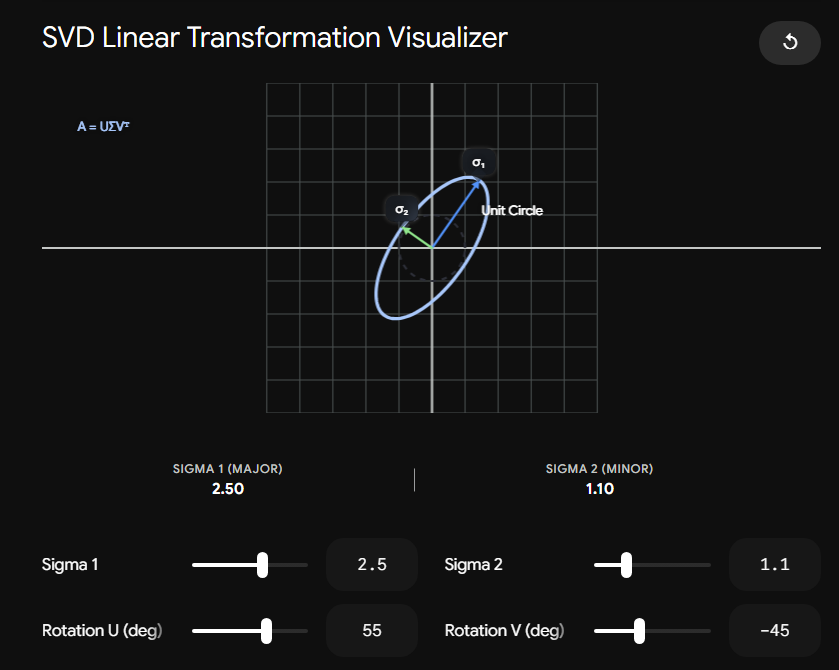

**工程意义：** <br>
在数据科学、深度学习与空间计算中，矩阵通常存放着海量的观测数据、图像像素或网络权重。奇异值在这里扮演了信息量（能量）量化指标的角色。<br>
实际物理和业务世界中的矩阵，其奇异值往往具有极快的衰减速度：前 5% 甚至前 1% 的奇异值极其庞大，占据了矩阵 90% 以上的变换能量；而后续绝大多数奇异值迅速衰减趋近于 $0$（代表由于噪声或冗余导致微不足道的拉伸）。

**通俗简明的解释：奇异值就是 LoRA 学到的权重变化，主要集中在多少个方向上。**<br>
奇异值越大，对应的 LoRA 更新方向越重要；同矩阵中奇异值下降越快，说明 LoRA 真正使用的有效 Rank 越低（例如[10 , 2 , 0.3 , 0.05 , 0.01]中 10 很快下降到 0.01）

奇异值越集中在前几个方向，说明虽然配置 Rank 为 8，但训练实际使用的有效维度更低。这里的 90%/99% 有效秩指覆盖对应比例 $\|\Delta W\|_F^2$ 所需的最少奇异值数量。

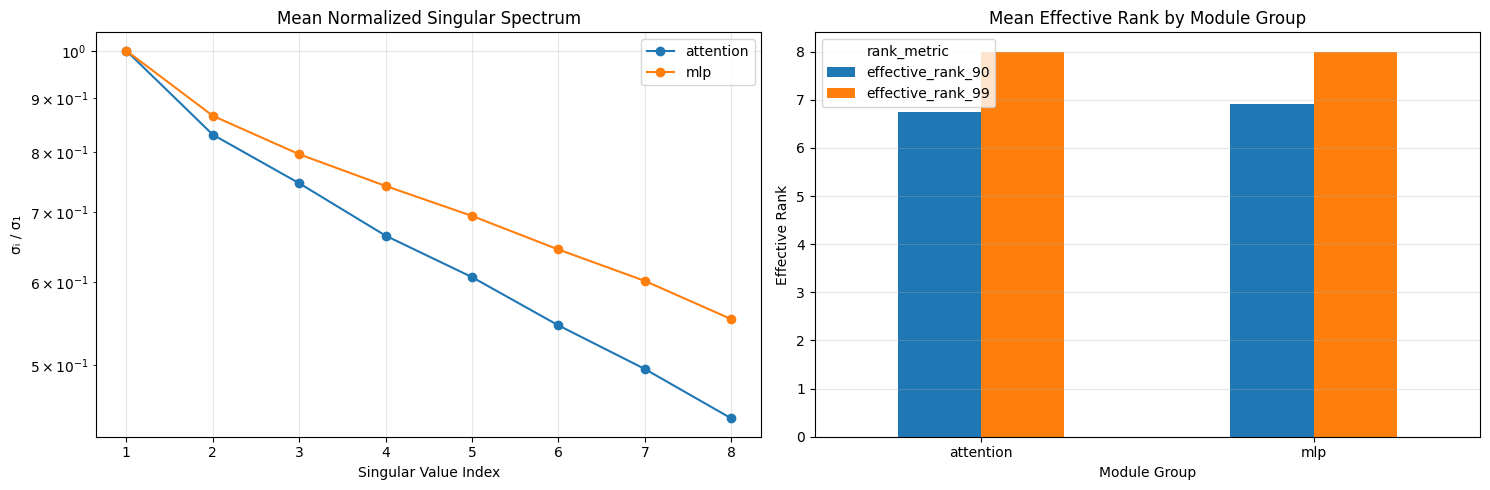

,layer_name,module_group,effective_rank_90,effective_rank_99,numerical_rank,stable_rank
41,model.layers.5.mlp.down_proj,mlp,3,7,8,1.410
0,model.layers.0.self_attn.q_proj,attention,5,8,8,1.803
1,model.layers.0.self_attn.k_proj,attention,5,8,8,2.000
64,model.layers.9.self_attn.k_proj,attention,6,8,8,2.184
128,model.layers.18.self_attn.v_proj,attention,6,8,8,2.203
2,model.layers.0.self_attn.v_proj,attention,6,8,8,2.279
162,model.layers.23.self_attn.k_proj,attention,6,8,8,2.516
65,model.layers.9.self_attn.v_proj,attention,6,8,8,2.677
50,model.layers.7.self_attn.k_proj,attention,6,8,8,2.717
130,model.layers.18.mlp.gate_proj,mlp,6,8,8,2.746


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mean_spectra = (
    singular_spectra_df.groupby(
        ['module_group', 'singular_index'], as_index=False
    )['normalized_singular_value'].mean()
)
for module_group, group_df in mean_spectra.groupby('module_group'):
    axes[0].plot(
        group_df['singular_index'],
        group_df['normalized_singular_value'],
        marker='o', label=module_group,
    )
axes[0].set(
    title='Mean Normalized Singular Spectrum',
    xlabel='Singular Value Index',
    ylabel='σᵢ / σ₁',
    yscale='log',
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

rank_plot_df = weight_analysis_df.melt(
    id_vars=['module_group'],
    value_vars=['effective_rank_90', 'effective_rank_99'],
    var_name='rank_metric', value_name='effective_rank',
)
rank_means = rank_plot_df.groupby(
    ['module_group', 'rank_metric']
)['effective_rank'].mean().unstack()
rank_means.plot(kind='bar', ax=axes[1])
axes[1].set(
    title='Mean Effective Rank by Module Group',
    xlabel='Module Group', ylabel='Effective Rank',
)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(
    weight_analysis_df[
        ['layer_name', 'module_group', 'effective_rank_90',
         'effective_rank_99', 'numerical_rank', 'stable_rank']
    ]
    .sort_values(['effective_rank_99', 'stable_rank'])
    .head(15)
    .style.format({'stable_rank': '{:.3f}'})
)


**左图[归一化奇异值]**<br>
第 i 个奇异值相对最大奇异值的比值：
$$
\frac{\sigma_i}{\sigma_1}
$$
- 观察到奇异值下降较慢，最小的第 8 个奇异值仍然分别约为最大奇异值的 44% 和 55%，并没有接近 0，Rank 没有设置过大（可以再调大一点看看）。如果 Rank 存在明显冗余，就能观察到奇异值快速下降。<br>
- MLP 比 Attention 下降更慢，说明 MLP 更充分地使用多个方向，而 Attention 更依赖前几个主方向。


**右图[平均有效秩]** <br>
要保留 LoRA 更新的 90% 或 99% 能量，平均需要保留多少个奇异方向？

**表格**：<br>
stable rank：整个奇异值谱相当于多少个“最大奇异值大小”的方向。
$$
\text{stable\_rank}(\Delta W) = \frac{\|\Delta W\|_2^2}{\|\Delta W\|_F^2} = \frac{\sigma_1^2}{\sum_i \sigma_i^2}
$$
- 尽管 8 个方向都在工作，但更新能量仍由少数较强方向主导。Stable Rank 越接近 1，能量越集中；越接近 8，八个方向越均匀。

## 4.2 层间差异可视化

$\text{relative\_update} = \frac{\|\Delta W\|_F}{\|W_0\|_F}$ 消除了不同投影矩阵尺寸和基础权重尺度的影响，比单独比较 $\|\Delta W\|_F$ 更适合判断哪些层被 LoRA 改动得更强。


层间差异用来描述：
>LoRA 对模型中的哪些层修改得更多，哪些层修改得更少。

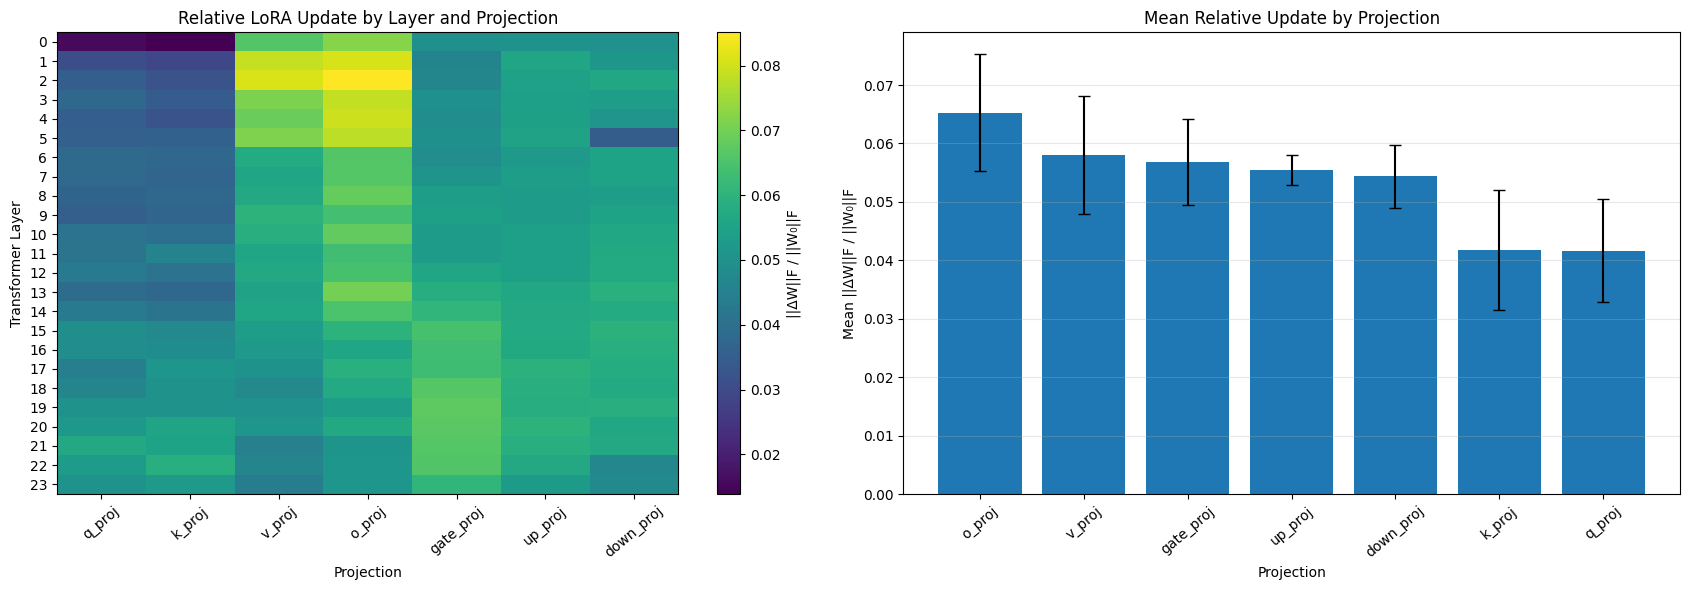

相对更新最大的 15 层：


,layer_name,module_group,projection,delta_fro_norm,base_fro_norm,relative_update
17,model.layers.2.self_attn.o_proj,attention,o_proj,1.2618,14.8217,8.5135%
16,model.layers.2.self_attn.v_proj,attention,v_proj,1.2559,15.4703,8.1183%
10,model.layers.1.self_attn.o_proj,attention,o_proj,1.1879,14.7036,8.0792%
31,model.layers.4.self_attn.o_proj,attention,o_proj,1.2794,16.0772,7.9577%
9,model.layers.1.self_attn.v_proj,attention,v_proj,1.1754,14.9035,7.8870%
24,model.layers.3.self_attn.o_proj,attention,o_proj,1.2452,15.8195,7.8710%
38,model.layers.5.self_attn.o_proj,attention,o_proj,1.3011,16.6745,7.8030%
3,model.layers.0.self_attn.o_proj,attention,o_proj,1.1039,15.3082,7.2114%
37,model.layers.5.self_attn.v_proj,attention,v_proj,1.2366,17.3623,7.1225%
23,model.layers.3.self_attn.v_proj,attention,v_proj,1.1450,16.1353,7.0965%


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

relative_pivot = weight_analysis_df.pivot(
    index='layer_index', columns='projection', values='relative_update'
)
projection_order = [
    name for name in
    ['q_proj', 'k_proj', 'v_proj', 'o_proj',
     'gate_proj', 'up_proj', 'down_proj']
    if name in relative_pivot.columns
]
relative_pivot = relative_pivot[projection_order]
heatmap = axes[0].imshow(relative_pivot.values, aspect='auto', cmap='viridis')
axes[0].set(
    title='Relative LoRA Update by Layer and Projection',
    xlabel='Projection', ylabel='Transformer Layer',
    xticks=range(len(relative_pivot.columns)),
    xticklabels=relative_pivot.columns,
    yticks=range(len(relative_pivot.index)),
    yticklabels=relative_pivot.index,
)
axes[0].tick_params(axis='x', rotation=40)
fig.colorbar(heatmap, ax=axes[0], label='||ΔW||F / ||W₀||F')

projection_stats = (
    weight_analysis_df.groupby('projection', as_index=False)
    .agg(
        mean_relative_update=('relative_update', 'mean'),
        std_relative_update=('relative_update', 'std'),
    )
    .sort_values('mean_relative_update', ascending=False)
)
axes[1].bar(
    projection_stats['projection'],
    projection_stats['mean_relative_update'],
    yerr=projection_stats['std_relative_update'],
    capsize=4,
)
axes[1].set(
    title='Mean Relative Update by Projection',
    xlabel='Projection', ylabel='Mean ||ΔW||F / ||W₀||F',
)
axes[1].tick_params(axis='x', rotation=40)
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('相对更新最大的 15 层：')
display(
    weight_analysis_df[
        ['layer_name', 'module_group', 'projection',
         'delta_fro_norm', 'base_fro_norm', 'relative_update']
    ]
    .sort_values('relative_update', ascending=False)
    .head(15)
    .style.format({
        'delta_fro_norm': '{:.4f}',
        'base_fro_norm': '{:.4f}',
        'relative_update': '{:.4%}',
    })
)


**参数：**<br>
- q_proj 、 k_proj ：决定 Token 之间如何匹配、关注谁；
- v_proj ：决定被关注的信息携带什么内容；
- o_proj ：将各注意力头输出重新混合到隐藏空间。

完整 Attention 流程

输入隐藏状态为 $\mathbf{X}$，先计算：
$$\mathbf{Q} = \mathbf{X}\mathbf{W}_Q,\quad \mathbf{K} = \mathbf{X}\mathbf{W}_K,\quad \mathbf{V} = \mathbf{X}\mathbf{W}_V$$

单头注意力为：
$$\mathbf{H} = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)\mathbf{V}$$

多头注意力会得到多个头：
$$\mathbf{H}_1, \mathbf{H}_2, \ldots, \mathbf{H}_h$$

先把它们拼接：
$$\mathbf{H}_{\text{concat}} = \text{Concat}(\mathbf{H}_1, \mathbf{H}_2, \ldots, \mathbf{H}_h)$$

最后通过输出投影：
$$\mathbf{O} = \mathbf{H}_{\text{concat}}\mathbf{W}_O$$

这里的 $\mathbf{W}_O$（可学习矩阵） 就是代码中的：
$$o_{proj}$$


**分析：**<br>
- 最大更新主要集中在浅层 Attention
- 更新最大不等于贡献最大
- 浅层 Attention 主要改“传什么、怎么输出”，深层 MLP 主要改“激活和组合什么特征”；Q/K 原有的关注关系被保留得更多。

## 4.3 与预训练权重的方向相似度

$$\cos(W_0, \Delta W)=\frac{\langle W_0, \Delta W\rangle}{\|W_0\|_F\|\Delta W\|_F}$$

- 接近 `+1`：更新主要增强原权重方向；
- 接近 `-1`：更新主要抵消原权重方向；
- 接近 `0`：更新整体与原权重近似正交，更偏向引入新方向。


方向相似度用来描述：
> LoRA 学到的更新方向，与预训练权重原来的方向是否一致。


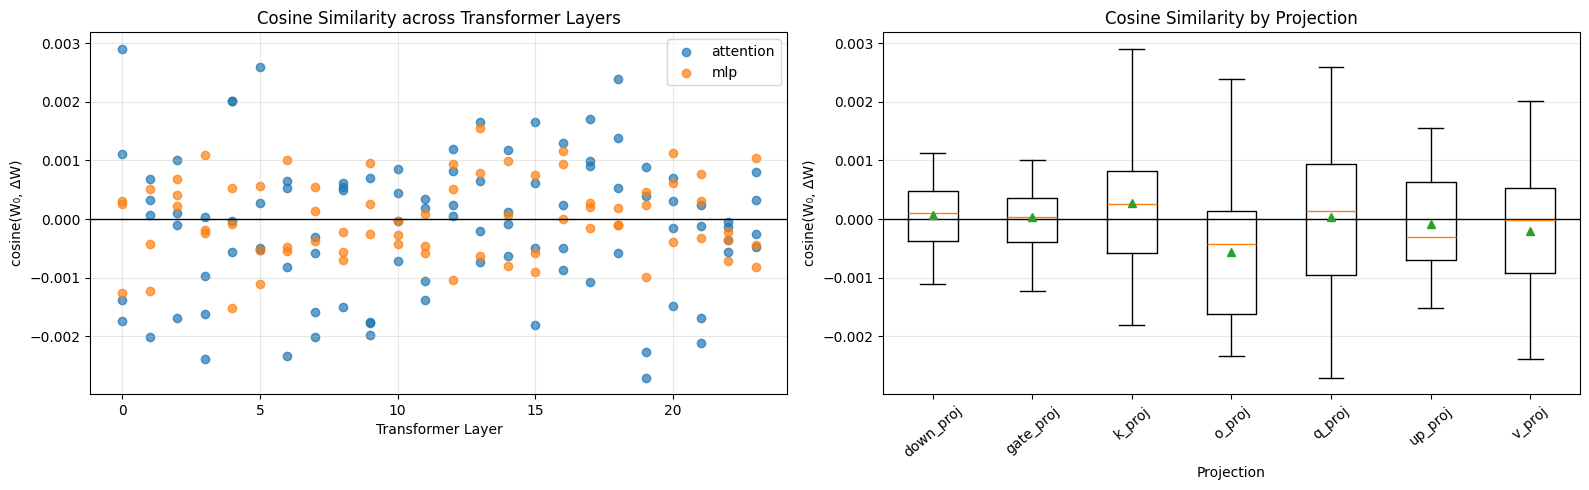

,layer_count
增强原方向 (cos > 0.1),0
近似正交 (|cos| ≤ 0.1),168
抵消原方向 (cos < -0.1),0


绝对余弦相似度最高的 15 层：


,layer_name,module_group,projection,cosine_w0_delta,abs_cosine
1,model.layers.0.self_attn.k_proj,attention,k_proj,0.0029,0.0029
133,model.layers.19.self_attn.q_proj,attention,q_proj,-0.0027,0.0027
35,model.layers.5.self_attn.q_proj,attention,q_proj,0.0026,0.0026
23,model.layers.3.self_attn.v_proj,attention,v_proj,-0.0024,0.0024
129,model.layers.18.self_attn.o_proj,attention,o_proj,0.0024,0.0024
45,model.layers.6.self_attn.o_proj,attention,o_proj,-0.0023,0.0023
136,model.layers.19.self_attn.o_proj,attention,o_proj,-0.0023,0.0023
150,model.layers.21.self_attn.o_proj,attention,o_proj,-0.0021,0.0021
51,model.layers.7.self_attn.v_proj,attention,v_proj,-0.0020,0.0020
10,model.layers.1.self_attn.o_proj,attention,o_proj,-0.0020,0.0020


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for module_group, group_df in weight_analysis_df.groupby('module_group'):
    axes[0].scatter(
        group_df['layer_index'], group_df['cosine_w0_delta'],
        alpha=0.7, label=module_group,
    )
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set(
    title='Cosine Similarity across Transformer Layers',
    xlabel='Transformer Layer', ylabel='cosine(W₀, ΔW)',
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

cosine_by_projection = weight_analysis_df.groupby(
    'projection'
)['cosine_w0_delta'].apply(list)
axes[1].boxplot(
    cosine_by_projection.tolist(),
    tick_labels=cosine_by_projection.index,
    showmeans=True,
)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(
    title='Cosine Similarity by Projection',
    xlabel='Projection', ylabel='cosine(W₀, ΔW)',
)
axes[1].tick_params(axis='x', rotation=40)
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

cosine_threshold = 0.1
direction_counts = pd.Series({
    '增强原方向 (cos > 0.1)': (
        weight_analysis_df['cosine_w0_delta'] > cosine_threshold
    ).sum(),
    '近似正交 (|cos| ≤ 0.1)': (
        weight_analysis_df['cosine_w0_delta'].abs() <= cosine_threshold
    ).sum(),
    '抵消原方向 (cos < -0.1)': (
        weight_analysis_df['cosine_w0_delta'] < -cosine_threshold
    ).sum(),
})
display(direction_counts.to_frame('layer_count'))

print('绝对余弦相似度最高的 15 层：')
display(
    weight_analysis_df.assign(
        abs_cosine=weight_analysis_df['cosine_w0_delta'].abs()
    )[
        ['layer_name', 'module_group', 'projection',
         'cosine_w0_delta', 'abs_cosine']
    ]
    .sort_values('abs_cosine', ascending=False)
    .head(15)
    .style.format({
        'cosine_w0_delta': '{:.4f}',
        'abs_cosine': '{:.4f}',
    })
)


所有 168 个 LoRA 更新 $\Delta W$ 与对应预训练权重 $W_0$ 的余弦相似度都极接近 0。说明 LoRA 没有简单地整体放大或缩小原权重，而是在参数空间中学习了近似正交的新变化方向。

| Cosine 值 | 含义 | 更新效果 |
|-----------|------|----------|
| 接近 +1 | 更新整体沿着原权重方向 | 主要增强原方向 |
| 接近 -1 | 更新整体与原权重相反 | 主要削弱原方向 |
| 接近 0 | 更新与原权重近似正交 | 引入不同的参数变化方向 |

本次结果都接近 0，说明 LoRA 没有简单地整体放大或缩小原权重，而是在参数空间中学习了近似正交的新变化方向。

## 4.4 解读原则

1. **配置 Rank 不等于有效 Rank**：`r=8` 只是允许的最大秩；若奇异值快速衰减、99% 能量秩显著小于 8，说明多个 LoRA 方向存在冗余。
2. **不要只比较 `||ΔW||F`**：大矩阵天然可能有更大的范数，应优先比较相对更新 `||ΔW||F / ||W₀||F`。
3. **Attention 与 MLP 的差异是任务相关的**：更新更大的模块通常承担更多当前任务适配，但不等于它对所有任务都更重要。
4. **余弦接近 0 不代表更新无效**：它表示 LoRA 更倾向于补充原权重缺少的方向；效果还取决于输入激活，不能仅凭权重余弦判断功能重要性。
5. **这是权重空间分析**：要进一步回答“哪些更新真正影响输出”，还需结合激活、梯度或逐层 Adapter 消融。


In [60]:
# 分析完成后可运行本单元释放模型显存；DataFrame 中的统计结果会保留
# del analysis_model, analysis_optimizer, analysis_dataloader
# gc.collect()
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()


# TODO

## 1. 消融实验（Ablation Study）
这是最直接的后续实验，帮助你理解 LoRA 各组件的作用：

- 不同 rank 对比 ： r=1, 2, 4, 8, 16, 32, 64 ，记录 loss 曲线和最终效果，观察 rank 与性能的关系
- 不同 alpha 对比 ：固定 r=8，改变 alpha 看缩放系数的影响
- 不同 target module 对比 ：只对 attention 的 Q/K/V 加 LoRA vs 全线性层 vs 只对 MLP 加
- 对比 Full Fine-tuning ：在你的 tiny llama 上跑全量微调，对比 LoRA 的效率和效果

## 2. LoRA 权重分析
深入理解 LoRA 学到了什么：

- 奇异值分析 ：对学到的 ΔW = B @ A 做 SVD 分解，看不同层的有效秩
- 层间差异可视化 ：哪些层的 LoRA 权重变化最大？attention 层和 MLP 层有什么不同？
- 与预训练权重的相似度 ：计算 cosine_similarity(W₀, ΔW) ，分析 LoRA 是增强了原方向还是引入了新方向

## 3. LoRA 变体实现
在你现有代码基础上实现论文中的改进：

- DoRA （Weight-Decomposed Low-Rank Adaptation）：将预训练权重分解为 magnitude + direction，只对 direction 做低秩更新。这是目前效果最好的 LoRA 变体之一。
- LoRA+ ：给 lora_A 和 lora_B 设置不同的学习率（λ_B / λ_A ≈ 2^r），训练更高效。
- AdaLoRA ：自适应分配不同层的 rank，重要的层给更高的 rank。

## 4. 多 Adapter 实验
LoRA 的一大优势是"插件式"部署：

- 在 bioinstruct 上训练一个 adapter，再在其他数据集（如 math、code）上各训练一个
- 实现 adapter 切换 ：同一个 base model 加载不同 adapter 完成不同任务
- 尝试 adapter 融合 ：对两个 adapter 的权重做线性插值，观察效果变化

## 5. 训练技巧补充
- 学习率调度器 ：加入 cosine/linear warmup scheduler，对比有无 scheduler 的效果
- 混合精度训练 ：用 torch.cuda.amp.autocast + GradScaler 加速训练
- 梯度累积 ：模拟更大 batch size（当显存不够时很实用）
- 与 PEFT 库对比 ：用 HuggingFace PEFT 库实现同样的 LoRA，对比你的实现

## 6. QLoRA 实验
在 LoRA 基础上加量化，这是实际部署中非常重要的技术：

- 用 bitsandbytes 把 base model 量化为 4-bit（NF4）
- 对比 QLoRA vs LoRA 的显存占用和训练速度
- 理解双重量化（Double Quantization）的作用

## 7. 评估体系完善
目前只有 loss，可以加入：

- Perplexity 计算（在验证集上）
- ROUGE/BLEU 等生成质量指标
- 在生物医学 QA 任务上的 accuracy 评估
- 画出 loss 曲线和 eval metric 曲线

# Reference

https://github.com/Mxoder/LLM-from-scratch